# Four SED methods: Poisson-fluctuated counts

Compare simultaneous default BinnedSED, simultaneous frozen-global-shape BinnedSED, individual measured-energy frozen-shape fits, and spectral-only Richardson–Lucy (RL). Both power laws (indices -1, -2, -3) and cutoff power laws (cutoffs 200, 1000, 5000 keV, index fixed at -2) use the same DC4 setup as the two-method companion notebooks.

The first three methods use 3ML/Minuit. RL uses positive ML-EM updates of incident-energy band fluxes at the exact fixed source position. It does not reconstruct an image or require a global spectral fit. All methods retain the angular Compton-data-space information and energy redistribution in the point-source response.

Background is free: one scale for each simultaneous fit and RL reconstruction, and a separate scale for each individual measured-energy fit. The individual method consequently has more background freedom than the simultaneous methods.

All source injection, fitting, tables and plots remain in memory or inline notebook outputs; no extra data, response-cache or plot files are saved. These new notebooks leave the original two-method comparisons unchanged.

The final section repeats all four methods at 24 months (eight times the original effective exposure), with fresh Poisson counts and the same physical injected spectra.

## Imports and configuration

The DC4 background was produced with a 60-degree field-of-view selection around the source, so the same cut is applied to the orientation in memory.

In [1]:
from copy import deepcopy
from pathlib import Path

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
from astromodels import Cutoff_powerlaw, Model, Parameter, PointSource, Powerlaw
from threeML import DataList, JointLikelihood, PluginPrototype, update_logging_level

from cosipy import BinnedData
from cosipy.data_io import EmCDSBinnedData
from cosipy.event_selection import GoodTimeInterval
from cosipy.response import BinnedInstrumentResponse, PointSourceResponse
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.response.integrals import get_integral_values
from cosipy.source_injector import SourceInjector
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.threeml import BinnedSED, profile_likelihood_upper_limit

update_logging_level("ERROR")
%matplotlib inline

DC4_DATA_DIR = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/"
    "COSI/Radio_Quiet_AGN/DC4_Files"
)
ORIENTATION_PATH = DC4_DATA_DIR / (
    "DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits"
)
RESPONSE_PATH = DC4_DATA_DIR / (
    "ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284."
    "filtered.nonsparse.binnedimaging.imagingresponse.h5"
)
BACKGROUND_PATH = DC4_DATA_DIR / (
    "Background/Total_DC4_BG_3months_binned_data_filtered_"
    "with_SAAcut_withSAAbck_NGC4151_60deg_fov_cut.hdf5"
)
CONFIG_PATH = Path("background.yaml")

SOURCE_COORD = SkyCoord(l=155.07 * u.deg, b=75.06 * u.deg, frame="galactic")
FOV_CUT = 60 * u.deg
POWERLAW_INDICES = (-1.0, -2.0, -3.0)
CUTOFF_ENERGIES_KEV = (200.0, 1000.0, 5000.0)
CUTOFF_INDEX = -2.0
PIVOT_KEV = 1000.0
INTEGRATED_PHOTON_FLUX = 5.0e-3
GLOBAL_START_K = 1.0e-7
SED_START_FLUXES = (1.0e-9, 1.0e-7, 1.0e-5)
TS_THRESHOLD = 4.0
RANDOM_SEED = 20260909
TINY = np.finfo(float).tiny
FLUX_UNIT = 1.0 / (u.keV * u.cm**2 * u.s)

RL_ITERATIONS = 1000
RL_CHECKPOINTS = (100, 300, 1000, 3000)
RL_INITIAL_BAND_FLUX = 1.0e-4  # photons cm^-2 s^-1 in each true-energy bin


10:58:09 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=49238;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=659475;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=8184;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=900536;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

10:58:10 WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=361284;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=907611;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

10:58:10 INFO      Starting 3ML!                                                                     ]8;id=970561;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=54774;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

WARNING   WARNINGs here are NOT errors                                                      ]8;id=971920;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=779664;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

WARNING   ROOT minimizer not available                                                ]8;id=659333;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minimization.py\minimization.py]8;;\:]8;id=493623;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minimization.py#1208\1208]8;;\

WARNING   Multinest minimizer not available                                           ]8;id=984353;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minimization.py\minimization.py]8;;\:]8;id=738198;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minimization.py#1218\1218]8;;\

WARNING   PyGMO is not available                                                      ]8;id=290136;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minimization.py\minimization.py]8;;\:]8;id=498669;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minimization.py#1228\1228]8;;\

10:58:11 WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=763097;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=861942;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

WARNING   No fermitools installed                                              ]8;id=280905;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=191075;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

## Load the response and background

Only the existing orientation, response, and background products are read. The injected source and combined data remain Python objects in memory.

In [2]:
def dense_values(histogram):
    values = histogram.contents
    if hasattr(values, "todense"):
        values = values.todense()
    if isinstance(values, u.Quantity):
        values = values.value
    return np.asarray(values, dtype=float)


for required_path in (ORIENTATION_PATH, RESPONSE_PATH, BACKGROUND_PATH, CONFIG_PATH):
    if not required_path.exists():
        raise FileNotFoundError(required_path)

background_data = BinnedData(CONFIG_PATH)
background_data.load_binned_data_from_hdf5(BACKGROUND_PATH)
background_hist = background_data.binned_data.project("Em", "Phi", "PsiChi")
background_counts = dense_values(background_hist)
data_definition = EmCDSBinnedData(background_hist)

orientation = SpacecraftHistory.open(ORIENTATION_PATH)
pointing_gti = GoodTimeInterval.from_pointing_cut(
    SOURCE_COORD, orientation, FOV_CUT, earth_occ=False
)
orientation = orientation.apply_gti(pointing_gti)

detector_response = FullDetectorResponse.open(RESPONSE_PATH)
instrument_response = BinnedInstrumentResponse(detector_response, data_definition)
scatt_map = orientation.get_scatt_map(
    nside=2 * data_definition.axes["PsiChi"].nside,
    target_coord=SOURCE_COORD,
    earth_occ=True,
)
point_response = PointSourceResponse.from_scatt_map(
    SOURCE_COORD,
    data_definition,
    instrument_response,
    scatt_map,
    detector_response.axes["Ei"],
    detector_response.axes["Pol"]
    if "Pol" in detector_response.axes.labels
    else None,
)
injector = SourceInjector(response_path=RESPONSE_PATH)

ei_edges = detector_response.axes["Ei"].edges
if isinstance(ei_edges, u.Quantity):
    ei_edges = ei_edges.to_value(u.keV)
ei_edges = np.asarray(ei_edges, dtype=float)
energy = np.sqrt(ei_edges[:-1] * ei_edges[1:])

print(f"Configuration: {CONFIG_PATH}")
print(f"Selected livetime: {orientation.cumulative_livetime().to_value(u.s):,.0f} s")
print(f"SED bins: {len(energy)} from {ei_edges[0]:g} to {ei_edges[-1]:g} keV")

Configuration: background.yaml
Selected livetime: 980,415 s
SED bins: 10 from 100 to 10000 keV


## Spectrum and likelihood helpers

Every injected spectrum has the same photon flux integrated over the response energy range. The likelihood is Poisson and forward folds the global model through the full point-source response on every Minuit evaluation.

In [3]:
def poisson_nll(data, model):
    data = np.asarray(data, dtype=float)
    model = np.clip(np.asarray(model, dtype=float), TINY, None)
    positive = data > 0.0
    value = np.sum(model[~positive])
    observed, expected = data[positive], model[positive]
    # Preserve the usual calculation, but avoid overflow in null fits when
    # a positive count is divided by the tiny floor of an empty template cell.
    with np.errstate(over="ignore", divide="ignore"):
        log_ratio = np.log(observed / expected)
    unstable = ~np.isfinite(log_ratio)
    if np.any(unstable):
        log_ratio[unstable] = (
            np.log(observed[unstable]) - np.log(expected[unstable])
        )
    value += np.sum(expected - observed + observed * log_ratio)
    return float(value)


def normalize_spectrum(shape, integrated_flux=INTEGRATED_PHOTON_FLUX):
    shape.set_units(u.keV, FLUX_UNIT)
    shape.K.value = 1.0
    coefficient = get_integral_values(
        shape, np.asarray([ei_edges[0], ei_edges[-1]], dtype=float)
    )[0]
    shape.K.value = float(integrated_flux / coefficient)
    return shape


def make_injected_spectrum(family, case_value):
    if family == "powerlaw":
        shape = Powerlaw()
        shape.piv.value = PIVOT_KEV
        shape.index.value = float(case_value)
    elif family == "cutoff_powerlaw":
        shape = Cutoff_powerlaw()
        shape.piv.value = PIVOT_KEV
        shape.index.value = CUTOFF_INDEX
        shape.xc.value = float(case_value)
    else:
        raise ValueError(f"Unknown family: {family}")
    return normalize_spectrum(shape)


def minuit_status(like):
    fmin = like.minimizer.minuit.fmin
    return {
        "valid": bool(getattr(fmin, "is_valid", False)),
        "edm": float(getattr(fmin, "edm", np.nan)),
        "call_limit": bool(getattr(fmin, "has_reached_call_limit", False)),
    }

In [4]:
class ForwardFoldedSpectrumPlugin(PluginPrototype):
    """Poisson plugin for a global spectrum plus one background scale."""

    def __init__(self, name, data, background, response, spectrum):
        self._data = np.asarray(data, dtype=float)
        self._background = np.asarray(background, dtype=float)
        self._response = response
        self._spectrum = spectrum
        parameter_name = f"{name}_background_scale"
        self.background_scale = Parameter(
            parameter_name, 1.0, min_value=0.0, max_value=10.0, delta=0.05
        )
        super().__init__(name, {parameter_name: self.background_scale})
        self._model = None

    def set_model(self, model):
        self._model = model

    def get_number_of_data_points(self):
        return int(self._data.size)

    def get_log_like(self):
        source = dense_values(self._response.get_expectation(self._spectrum))
        model = source + float(self.background_scale.value) * self._background
        return -poisson_nll(self._data, model)

    def inner_fit(self):
        return self.get_log_like()


def configured_global_shape(family, start_value):
    if family == "powerlaw":
        shape = Powerlaw()
        shape.index.value = float(start_value)
        shape.index.min_value = -4.5
        shape.index.max_value = -0.5
        shape.index.delta = 0.1
        shape.index.free = True
    elif family == "cutoff_powerlaw":
        shape = Cutoff_powerlaw()
        shape.index.value = CUTOFF_INDEX
        shape.index.free = False
        shape.xc.value = float(start_value)
        shape.xc.min_value = 100.0
        shape.xc.max_value = 20000.0
        shape.xc.delta = 0.1 * float(start_value)
        shape.xc.free = True
    else:
        raise ValueError(f"Unknown family: {family}")

    shape.piv.value = PIVOT_KEV
    shape.piv.free = False
    shape.K.value = GLOBAL_START_K
    shape.K.min_value = 1.0e-12
    shape.K.max_value = 1.0e-2
    shape.K.delta = 0.2 * GLOBAL_START_K
    shape.K.free = True
    shape.set_units(u.keV, FLUX_UNIT)
    return shape


def fit_global_spectrum(data, family, tag, *, response=None, background=None):
    response = point_response if response is None else response
    background = background_counts if background is None else background
    starts = POWERLAW_INDICES if family == "powerlaw" else CUTOFF_ENERGIES_KEV
    candidates = []
    diagnostics = []

    for trial, start_value in enumerate(starts):
        shape = configured_global_shape(family, start_value)
        source = PointSource(
            f"global_source_{tag}_{trial}",
            l=SOURCE_COORD.galactic.l.deg,
            b=SOURCE_COORD.galactic.b.deg,
            spectral_shape=shape,
        )
        plugin = ForwardFoldedSpectrumPlugin(
            f"global_plugin_{tag}_{trial}",
            data, background, response, shape,
        )
        like = JointLikelihood(
            Model(source), DataList(plugin), verbose=False, record=False
        )
        like.set_minimizer("minuit")

        try:
            like.fit(quiet=True, compute_covariance=False)
            status = minuit_status(like)
            nll = float(like.current_minimum)
            error = ""
        except Exception as exc:
            status = {"valid": False, "edm": np.nan, "call_limit": False}
            nll = np.inf
            error = f"{type(exc).__name__}: {exc}"

        diagnostics.append(
            {
                "family": family, "tag": tag, "start": start_value,
                "nll": nll, "error": error, **status,
            }
        )
        if status["valid"] and np.isfinite(nll):
            candidates.append(
                {
                    "nll": nll,
                    "shape": deepcopy(shape),
                    "background_scale": float(plugin.background_scale.value),
                }
            )

    if not candidates:
        table = pd.DataFrame(diagnostics)
        raise RuntimeError(f"No valid global fit for {tag}:\n{table}")

    best = min(candidates, key=lambda row: row["nll"])
    best["diagnostics"] = pd.DataFrame(diagnostics)
    return best

## Likelihood fitting helpers

All SED amplitudes and the relevant background scale are free. Both simultaneous methods retain identical data-independent Minuit starts. Manual per-bin TS refits fix the tested amplitude to zero and profile the remaining free amplitudes and background. TS < 4 selects nominal 95% upper limits.

As in the companions, upper limits use a conditional scan: the other parameters are held at their best-fit values during the scan. These are not fully nuisance-profiled limits; uncertainty in the fitted global shape is not propagated.

For individual fits, the full frozen global spectrum is folded first and then sliced in measured energy. This includes incoming photons from all incident-energy bins, but assumes their relative contributions follow the global shape. The single BinnedSED normalization is only a parameter container for this full-spectrum template; it is not folded as an isolated true-energy band.

If Minuit's final covariance refinement fails at a zero-flux boundary, the best valid multi-start solution is retained. Errors then use the analytic observed likelihood Hessian in external amplitude coordinates, including the free background. This local covariance fallback is flagged in the tables; it does not change the optimizer or turn boundary errors into calibrated intervals.

In [5]:
def analytic_template_errors(data, background, templates, reference_flux, fluxes, background_scale):
    """External-coordinate observed-Hessian errors, including free background.

    Scale parameters to expected counts for numerical conditioning. This is
    a local unconstrained covariance approximation, not a boundary interval.
    """
    derivatives = np.vstack([
        np.asarray(templates).reshape(len(fluxes), -1) / reference_flux,
        np.asarray(background).ravel(),
    ])
    scales = derivatives.sum(axis=1)
    normalized = derivatives / scales[:, None]
    model = np.asarray(fluxes) @ derivatives[:-1] + background_scale * derivatives[-1]
    observed = np.asarray(data).ravel()
    supported = (observed > 0) & (model > 0)
    weighted = normalized[:, supported] * (np.sqrt(observed[supported]) / model[supported])
    hessian = weighted @ weighted.T
    # Equilibrate curvature before inversion: cutoff tails can span many
    # decades in variance without the correlation matrix being singular.
    diagonal = np.sqrt(np.maximum(np.diag(hessian), 0.0))
    errors = np.full(len(scales), np.nan)
    active = diagonal > 0
    correlation = hessian[np.ix_(active, active)] / np.outer(diagonal[active], diagonal[active])
    if not np.all(np.isfinite(correlation)) or np.linalg.cond(correlation) > 1e12:
        return errors[:-1]  # genuinely unconstrained covariance; no invented bars
    inverse = np.linalg.inv(correlation)
    errors[active] = np.sqrt(np.maximum(np.diag(inverse), 0.0)) / diagonal[active] / scales[active]
    return errors[:-1]


class BinnedSEDTemplatePlugin(PluginPrototype):
    """Poisson plugin driven by BinnedSED normalization parameters."""

    def __init__(self, name, data, background, templates, source_name, reference_flux):
        self._data = np.asarray(data, dtype=float).ravel()
        self._background = np.asarray(background, dtype=float).ravel()
        self._source_name = source_name
        self._templates = np.asarray(templates, dtype=float).reshape(len(templates), -1)
        self._reference_flux = float(reference_flux)
        parameter_name = f"{name}_background_scale"
        self.background_scale = Parameter(
            parameter_name, 1.0, min_value=0.0, max_value=10.0, delta=0.05
        )
        super().__init__(name, {parameter_name: self.background_scale})
        self._model = None

    def set_model(self, model):
        self._model = model

    def get_number_of_data_points(self):
        return int(self._data.size)

    def get_log_like(self):
        spectrum = self._model[self._source_name].spectrum.main.shape
        fluxes = np.asarray(
            [parameter.value for parameter in spectrum.normalizations], dtype=float
        )
        model = (
            float(self.background_scale.value) * self._background
            + np.sum(
                fluxes[:, None] / self._reference_flux * self._templates, axis=0
            )
        )
        return -poisson_nll(self._data, model)

    def inner_fit(self):
        return self.get_log_like()


def folded_sed_templates(spectrum, reference_flux, response=None):
    response = point_response if response is None else response
    templates = []
    saved = np.asarray([p.value for p in spectrum.normalizations], dtype=float)
    try:
        for parameter in spectrum.normalizations:
            parameter.value = 0.0
        for parameter in spectrum.normalizations:
            parameter.value = reference_flux
            templates.append(dense_values(response.get_expectation(spectrum)))
            parameter.value = 0.0
    finally:
        for parameter, value in zip(spectrum.normalizations, saved):
            parameter.value = float(value)
    return np.asarray(templates)


def fit_binned_sed(data, tag, spectral_shape=None, measured_bin=None, *,
                   response=None, background=None):
    """Joint true-energy fit, or the branch's one measured-energy-slice fit."""
    response = point_response if response is None else response
    background = background_counts if background is None else background
    selected = None if measured_bin is None else [int(measured_bin)]
    n_parameters = len(energy) if selected is None else 1
    reference_flux = SED_START_FLUXES[1]
    spectrum = BinnedSED.from_response(
        detector_response,
        spectral_shape=spectral_shape,
        initial_fluxes=np.full(n_parameters, reference_flux),
        ei_bin_indices=selected,
    )
    source_name = f"sed_source_{tag}"
    source = PointSource(
        source_name,
        l=SOURCE_COORD.galactic.l.deg,
        b=SOURCE_COORD.galactic.b.deg,
        spectral_shape=spectrum,
    )
    parameters = tuple(spectrum.normalizations)
    if measured_bin is None:
        templates = folded_sed_templates(spectrum, reference_flux, response)
        fit_data, fit_background = data, background
    else:
        # Fold ALL incident energies before selecting a measured-energy slice.
        # K0 labels the inferred differential flux at this slice's pivot; the
        # plugin uses the full-spectrum template, not the one-bin model fold.
        if spectral_shape is None:
            raise ValueError("An individual fit requires the frozen global shape.")
        full_template = dense_values(response.get_expectation(spectral_shape))
        pivot_flux = float(spectral_shape(energy[measured_bin]))
        if not np.isfinite(pivot_flux) or pivot_flux <= 0:
            raise ValueError("The global spectrum must be positive at the pivot.")
        templates = np.asarray([
            full_template[measured_bin] * (reference_flux / pivot_flux)
        ])
        fit_data = data[measured_bin]
        fit_background = background[measured_bin]
    plugin = BinnedSEDTemplatePlugin(
        f"sed_plugin_{tag}",
        fit_data, fit_background, templates, source_name, reference_flux,
    )
    like = JointLikelihood(
        Model(source), DataList(plugin), verbose=False, record=False
    )
    like.set_minimizer("minuit")

    candidates = []
    diagnostics = []
    first_exception = None
    for start_flux in SED_START_FLUXES:
        for parameter in parameters:
            parameter.value = start_flux
            parameter.delta = 0.2 * start_flux
            parameter.free = True
        plugin.background_scale.value = 1.0
        plugin.background_scale.free = True

        try:
            like.fit(quiet=True, compute_covariance=False)
            status = minuit_status(like)
            nll = float(like.current_minimum)
            error = ""
        except Exception as exc:
            if first_exception is None:
                first_exception = exc
            status = {"valid": False, "edm": np.nan, "call_limit": False}
            nll = np.inf
            error = f"{type(exc).__name__}: {exc}"

        diagnostics.append(
            {"tag": tag, "start_flux": start_flux, "nll": nll,
             "error": error, **status}
        )
        if status["valid"] and np.isfinite(nll):
            candidates.append(
                (
                    nll,
                    np.asarray([p.value for p in parameters], dtype=float),
                    float(plugin.background_scale.value),
                )
            )

    if not candidates:
        table = pd.DataFrame(diagnostics)
        raise RuntimeError(
            f"No valid BinnedSED fit for {tag}:\n{table}"
        ) from first_exception

    best_nll, best_fluxes, best_background = min(candidates, key=lambda row: row[0])
    for parameter, value in zip(parameters, best_fluxes):
        parameter.value = float(value)
        parameter.delta = max(0.2 * float(value), 1.0e-12)
    plugin.background_scale.value = best_background
    try:
        like.fit(quiet=True, compute_covariance=True)
        covariance_valid = (
            minuit_status(like)["valid"]
            and float(like.current_minimum) <= best_nll + 1e-6
        )
    except Exception:
        covariance_valid = False
    if not covariance_valid:
        # HESSE can fail at near-zero band boundaries. Do not replace a
        # valid multi-start solution with an invalid covariance refinement.
        for parameter, value in zip(parameters, best_fluxes):
            parameter.value = float(value)
        plugin.background_scale.value = best_background
    baseline_fluxes = np.asarray([p.value for p in parameters], dtype=float)
    baseline_background = float(plugin.background_scale.value)
    baseline_nll = -float(plugin.get_log_like())

    errors = []
    for parameter in parameters:
        minuit_name = parameter.path.replace(".", "_")
        try:
            errors.append(float(like.minimizer.minuit.errors[minuit_name]))
        except Exception:
            errors.append(np.nan)
    error_method = "Minuit HESSE"
    if not covariance_valid or not np.all(np.isfinite(errors)):
        errors = analytic_template_errors(
            fit_data, fit_background, templates, reference_flux,
            baseline_fluxes, baseline_background,
        )
        error_method = "analytic observed Hessian (fallback)"
        if not np.all(np.isfinite(errors)):
            error_method += "; unavailable for singular directions"
    diagnostics.append({
        "tag": tag, "start_flux": np.nan, "nll": baseline_nll,
        "valid": True, "edm": np.nan, "call_limit": False,
        "error": "", "error_method": error_method,
        "covariance_refinement_accepted": covariance_valid,
    })

    # Manual per-bin profile-likelihood TS: set K_i=0, keep it fixed,
    # and refit every other SED normalization and the background scale.
    ts_values = []
    ts_diagnostics = []
    for bin_index, parameter in enumerate(parameters):
        for other_parameter, value in zip(parameters, baseline_fluxes):
            other_parameter.value = float(value)
            other_parameter.free = True
        plugin.background_scale.value = baseline_background
        plugin.background_scale.free = True
        parameter.value = 0.0
        parameter.free = False
        like.fit(quiet=True, compute_covariance=False)
        if not minuit_status(like)["valid"]:
            raise RuntimeError(f"Invalid TS null fit: {tag}, bin {bin_index}")
        null_nll = float(like.current_minimum)
        raw_ts = 2.0 * (null_nll - baseline_nll)
        ts_values.append(max(0.0, raw_ts))
        ts_diagnostics.append(
            {"bin": bin_index,
             "null_nll": null_nll,
             "alternative_nll": baseline_nll,
             "TS": max(0.0, raw_ts),
             "background_scale": float(plugin.background_scale.value),
             "background_free": bool(plugin.background_scale.free)}
        )

    # Restore the stable alternative fit after the null scans.
    for parameter, value in zip(parameters, baseline_fluxes):
        parameter.value = float(value)
        parameter.free = True
    plugin.background_scale.value = baseline_background
    plugin.background_scale.free = True

    ts_values = np.asarray(ts_values, dtype=float)
    is_ul = ts_values < TS_THRESHOLD
    ul95 = np.full(len(parameters), np.nan, dtype=float)
    for bin_index in np.flatnonzero(is_ul):
        parameter = parameters[bin_index]

        def conditional_nll(value):
            saved_value = float(parameter.value)
            parameter.value = float(value)
            try:
                return -float(plugin.get_log_like())
            finally:
                parameter.value = saved_value

        ul95[bin_index] = profile_likelihood_upper_limit(
            conditional_nll,
            nll_best=baseline_nll,
            best_value=baseline_fluxes[bin_index],
            sigma=errors[bin_index],
            max_value=parameter.max_value,
        )

    return {
        "spectrum": spectrum,
        "error_method": error_method,
        "templates": templates,
        "reference_flux": reference_flux,
        "background_free": bool(plugin.background_scale.free),
        "flux": baseline_fluxes,
        "error": np.asarray(errors, dtype=float),
        "TS": ts_values,
        "is_ul": is_ul,
        "ul95": ul95,
        "background_scale": baseline_background,
        "nll": baseline_nll,
        "diagnostics": pd.DataFrame(diagnostics),
        "ts_diagnostics": pd.DataFrame(ts_diagnostics),
    }

## Individual measured-energy helper

Uses the branch's full-spectrum folded template in each Em slice, with a free slice-specific background. Its reported true-energy band flux remains a model-dependent inference.

In [6]:
def band_conversion(shape):
    """Integrated photon flux per unit differential flux at each bin pivot."""
    return (
        np.asarray(get_integral_values(shape, ei_edges), dtype=float)
        / np.asarray(shape(energy), dtype=float)
    )


def fit_individual_frozen_shape(data, tag, global_shape, *, response=None, background=None):
    # This comparison assigns each Em slice to the corresponding Ei interval.
    # Refuse mismatched grids rather than silently using the wrong intervals.
    em_edges = data_definition.axes["Em"].edges
    if isinstance(em_edges, u.Quantity):
        em_edges = em_edges.to_value(u.keV)
    np.testing.assert_allclose(em_edges, ei_edges, rtol=1e-6)
    results = [
        fit_binned_sed(
            data, f"{tag}_em_{i}", spectral_shape=global_shape, measured_bin=i,
            response=response, background=background
        )
        for i in range(len(energy))
    ]
    return {
        key: np.asarray([result[key][0] for result in results])
        for key in ("flux", "error", "TS", "is_ul", "ul95")
    } | {
        "background_scale": np.asarray([r["background_scale"] for r in results]),
        "background_free": all(r["background_free"] for r in results),
        "error_method": np.asarray([r["error_method"] for r in results]),
        "diagnostics": pd.concat(
            [r["diagnostics"].assign(measured_bin=i) for i, r in enumerate(results)],
            ignore_index=True,
        ),
        "ts_diagnostics": pd.concat(
            [r["ts_diagnostics"].assign(measured_bin=i) for i, r in enumerate(results)],
            ignore_index=True,
        ),
        "band_factor": band_conversion(global_shape),
    }


## Spectral-only RL helper

The response is evaluated at the exact source coordinate. Only the incident-energy amplitudes and one background normalization are updated; no sky pixels are reconstructed. A temporary reference SED is used solely to extract unit-band response columns, and cancels algebraically.

In [7]:
# Build unit-integrated-flux response columns using the same folding path as
# the SED methods. The temporary E^-2 shape cancels in this normalization.
# Thus RL needs neither a global fit nor an assumed parametric source spectrum.
reference_sed = BinnedSED.from_response(
    detector_response, initial_fluxes=np.full(len(energy), SED_START_FLUXES[1])
)
reference_sed.set_units(u.keV, FLUX_UNIT)
reference_templates = folded_sed_templates(reference_sed, SED_START_FLUXES[1])
reference_band_flux = SED_START_FLUXES[1] * band_conversion(reference_sed.spectral_shape)
rl_response = reference_templates.reshape(len(energy), -1) / reference_band_flux[:, None]
energy_widths = np.diff(ei_edges)
assert np.all(np.isfinite(rl_response)) and np.all(rl_response >= 0)


def run_spectral_rl(data, response_matrix=None, *, background=None):
    """Spectral-only ML-EM with a jointly updated non-negative background scale.

    Response units: cm^2 s. Source amplitudes: photons cm^-2 s^-1 per Ei bin.
    All updates use the same previous expectation (including the background).
    No imaging, smoothing, parametric global spectrum, TS or UL calculation.
    """
    response_matrix = rl_response if response_matrix is None else response_matrix
    background = background_counts if background is None else background
    observed = np.asarray(data, dtype=float).ravel()
    background = np.asarray(background, dtype=float).ravel()
    matrix = np.asarray(response_matrix, dtype=float)
    exposure = matrix.sum(axis=1)
    if np.any(exposure <= 0) or background.sum() <= 0:
        raise ValueError("Source bands and background require positive exposure.")
    band_flux = np.full(len(exposure), RL_INITIAL_BAND_FLUX)
    background_scale = 1.0
    checkpoints = sorted(set(RL_CHECKPOINTS) | {RL_ITERATIONS})
    expectation = background_scale * background + band_flux @ matrix
    trace = [poisson_nll(observed, expectation)]
    snapshots = {}
    for iteration in range(1, max(checkpoints) + 1):
        ratio = np.divide(
            observed, expectation, out=np.zeros_like(observed), where=expectation > 0
        )
        source_factor = np.einsum("ij,j->i", matrix, ratio) / exposure
        background_factor = np.dot(background, ratio) / background.sum()
        band_flux *= source_factor
        background_scale *= background_factor
        expectation = (
            background_scale * background
            + np.einsum("i,ij->j", band_flux, matrix)
        )
        nll = poisson_nll(observed, expectation)
        if nll > trace[-1] + 1e-7 * max(1.0, abs(trace[-1])):
            raise RuntimeError("RL likelihood decreased beyond numerical tolerance.")
        trace.append(nll)
        if iteration in checkpoints:
            snapshots[iteration] = {
                "band_flux": band_flux.copy(),
                "background_scale": float(background_scale),
                "nll": nll,
                "max_fractional_update": float(max(
                    np.max(np.abs(source_factor - 1.0)),
                    abs(background_factor - 1.0),
                )),
            }
    chosen = snapshots[RL_ITERATIONS]
    return {
        **chosen,
        "flux": chosen["band_flux"] / energy_widths,
        "nll_trace": np.asarray(trace),
        "snapshots": snapshots,
        "iterations": RL_ITERATIONS,
        "background_free": True,
    }


## Generate fluctuated counts and perform the global fits

`data_save_path=None` makes `SourceInjector` return the expected source histogram without creating an HDF5 file. We draw independent Poisson counts in every measured-energy/Compton-data-space cell with mean `source_counts + background_counts`. Sampling the sum is equivalent to independently sampling and adding source and background counts.

The background template remains the expected background, not a second noisy realization; its scale is free in the global fit and both SED fits. This simulates counting noise in the observations, but not uncertainty in the background template or response.

A fixed seed and separate random streams per case make rerunning this cell reproducible. Change `RANDOM_SEED` to explore another realization. Each realization is reused for the global fit and both SED methods; there is no resampling between methods.

In [8]:
case_definitions = [
    *(
        {"family": "powerlaw", "case_value": index,
         "case_label": rf"$\alpha={index:g}$"}
        for index in POWERLAW_INDICES
    ),
    *(
        {"family": "cutoff_powerlaw", "case_value": cutoff,
         "case_label": rf"$E_c={cutoff:g}$ keV"}
        for cutoff in CUTOFF_ENERGIES_KEV
    ),
]

comparison_runs = []
global_diagnostics = []
count_rows = []
case_seeds = np.random.SeedSequence(RANDOM_SEED).spawn(len(case_definitions))

for case_number, case in enumerate(case_definitions):
    family = case["family"]
    case_value = float(case["case_value"])
    tag = f"{family}_{case_number}"
    truth_shape = make_injected_spectrum(family, case_value)

    injected_hist = injector.inject_point_source(
        spectrum=truth_shape,
        coordinate=SOURCE_COORD,
        orientation=orientation,
        source_name=tag,
        data_save_path=None,
        project_axes=["Em", "Phi", "PsiChi"],
        earth_occ=True,
    )
    source_counts = dense_values(injected_hist)
    if source_counts.shape != background_counts.shape:
        raise ValueError(
            f"Source shape {source_counts.shape} does not match "
            f"background shape {background_counts.shape}."
        )
    expected_counts = background_counts + source_counts
    if not np.all(np.isfinite(expected_counts)) or np.any(expected_counts < 0):
        raise ValueError("Poisson expectations must be finite and non-negative.")
    rng = np.random.default_rng(case_seeds[case_number])
    data = rng.poisson(expected_counts)
    count_rows.append({
        "family": family,
        "case": case["case_label"],
        "expected_source_counts": float(source_counts.sum()),
        "expected_background_counts": float(background_counts.sum()),
        "expected_total_counts": float(expected_counts.sum()),
        "observed_total_counts": int(data.sum()),
        "total_count_pull": (
            (data.sum() - expected_counts.sum()) / np.sqrt(expected_counts.sum())
        ),
    })
    global_fit = fit_global_spectrum(data, family, tag)
    global_diagnostics.append(global_fit["diagnostics"])
    comparison_runs.append(
        {**case, "tag": tag, "truth_shape": truth_shape,
         "global_fit": global_fit, "data": data}
    )

print(f"Poisson seed: {RANDOM_SEED}; one shared realization per case")
count_summary = pd.DataFrame(count_rows)
display(count_summary)

global_rows = []
for run in comparison_runs:
    shape = run["global_fit"]["shape"]
    global_rows.append(
        {
            "family": run["family"],
            "case": run["case_label"],
            "fitted_K": float(shape.K.value),
            "fitted_index": float(shape.index.value),
            "fitted_cutoff_keV": (
                float(shape.xc.value) if hasattr(shape, "xc") else np.nan
            ),
            "background_scale": run["global_fit"]["background_scale"],
            "nll": run["global_fit"]["nll"],
        }
    )
global_fit_table = pd.DataFrame(global_rows)
display(global_fit_table)

global_start_diagnostics = pd.concat(global_diagnostics, ignore_index=True)
display(global_start_diagnostics)

Poisson seed: 20260909; one shared realization per case


,family,case,expected_source_counts,expected_background_counts,expected_total_counts,observed_total_counts,total_count_pull
0,powerlaw,$\alpha=-1$,223657.386581,25071034.0,2.529469e+07,25294046,-0.128323
1,powerlaw,$\alpha=-2$,214369.852251,25071034.0,2.528540e+07,25275252,-2.018879
2,powerlaw,$\alpha=-3$,156267.994688,25071034.0,2.522730e+07,25230489,0.634523
3,cutoff_powerlaw,$E_c=200$ keV,152491.552691,25071034.0,2.522353e+07,25225733,0.439529
4,cutoff_powerlaw,$E_c=1000$ keV,199327.598596,25071034.0,2.527036e+07,25276677,1.256305
5,cutoff_powerlaw,$E_c=5000$ keV,212373.502115,25071034.0,2.528341e+07,25268477,-2.969317


,family,case,fitted_K,fitted_index,fitted_cutoff_keV,background_scale,nll
0,powerlaw,$\alpha=-1$,1.103268e-06,-0.986731,NaN,0.999864,100102.345125
1,powerlaw,$\alpha=-2$,5.228280e-07,-1.943750,NaN,0.999807,99378.387374
2,powerlaw,$\alpha=-3$,1.007719e-07,-2.996825,NaN,1.000109,99756.990924
3,cutoff_powerlaw,$E_c=200$ keV,1.493791e-06,-2.000000,201.626692,1.000180,99395.820818
4,cutoff_powerlaw,$E_c=1000$ keV,6.921228e-07,-2.000000,1021.804612,1.000193,99321.148711
5,cutoff_powerlaw,$E_c=5000$ keV,5.440725e-07,-2.000000,4402.790542,0.999558,99416.835026


,family,tag,start,nll,error,valid,edm,call_limit
0,powerlaw,powerlaw_0,-1.0,100102.345125,,True,7.337662e-07,False
1,powerlaw,powerlaw_0,-2.0,100102.345125,,True,9.752863e-07,False
2,powerlaw,powerlaw_0,-3.0,100102.345125,,True,7.118015e-07,False
3,powerlaw,powerlaw_1,-1.0,99378.387375,,True,1.158972e-06,False
4,powerlaw,powerlaw_1,-2.0,99378.387374,,True,1.843621e-07,False
5,powerlaw,powerlaw_1,-3.0,99378.387383,,True,9.194153e-06,False
6,powerlaw,powerlaw_2,-1.0,99756.990935,,True,1.208188e-05,False
7,powerlaw,powerlaw_2,-2.0,99756.990925,,True,1.553211e-06,False
8,powerlaw,powerlaw_2,-3.0,99756.990924,,True,5.841534e-07,False
9,cutoff_powerlaw,cutoff_powerlaw_3,200.0,99395.820822,,True,3.579692e-06,False


## Run the four methods on identical data

Each case shares one data array across all four methods. The individual method has one free source normalization and one free background scale per measured-energy slice. The simultaneous methods and RL use all measured-energy slices together.

The RL response is expressed per unit integrated incident-bin flux. Its nominal SED is the 1000-iteration result; later checkpoints are diagnostics, not a truth-selected stopping rule. No RL TS, upper limits, or error bars are calculated.

In [9]:
sed_rows = []
sed_diagnostics = []
sed_ts_diagnostics = []
rl_checkpoint_rows = []
equivalence_rows = []

for run in comparison_runs:
    print(f"Fitting {run['family']}: {run['case_label']}", flush=True)
    data = run["data"]
    global_shape = run["global_fit"]["shape"]
    fits = {
        "default E^-2": fit_binned_sed(data, f"{run['tag']}_default"),
        "global fitted shape": fit_binned_sed(
            data, f"{run['tag']}_global_shape", spectral_shape=global_shape
        ),
        "individual frozen shape": fit_individual_frozen_shape(
            data, f"{run['tag']}_individual", global_shape
        ),
    }
    # Check the response normalization independently of the SED pivots.
    true_band_flux = np.asarray(get_integral_values(run["truth_shape"], ei_edges))
    truth_fold = dense_values(point_response.get_expectation(run["truth_shape"])).ravel()
    np.testing.assert_allclose(true_band_flux @ rl_response, truth_fold, rtol=1e-10, atol=1e-10)
    rl_fit = run_spectral_rl(data)
    fits["spectral RL"] = rl_fit
    run["sed_fits"] = fits
    run["truth_band_flux"] = true_band_flux
    truth_center = np.asarray(run["truth_shape"](energy), dtype=float)
    for method, fit in fits.items():
        is_rl = method == "spectral RL"
        assert fit["background_free"]
        if not is_rl:
            assert fit["ts_diagnostics"]["background_free"].all()
            sed_diagnostics.append(fit["diagnostics"].assign(
                family=run["family"], case=run["case_label"], method=method
            ))
            sed_ts_diagnostics.append(fit["ts_diagnostics"].assign(
                family=run["family"], case=run["case_label"], method=method
            ))
            factor = (
                fit["band_factor"] if method == "individual frozen shape"
                else band_conversion(fit["spectrum"].spectral_shape)
            )
            fit["band_flux"] = fit["flux"] * factor
            fit["band_factor"] = factor
        for i in range(len(energy)):
            truth_value = true_band_flux[i] / energy_widths[i] if is_rl else truth_center[i]
            background = np.broadcast_to(fit["background_scale"], energy.shape)[i]
            sed_rows.append({
                "family": run["family"], "case": run["case_label"],
                "case_value": run["case_value"], "method": method, "bin": i,
                "energy_keV": energy[i], "flux": fit["flux"][i],
                "flux_error": np.nan if is_rl else fit["error"][i],
                "error_method": ("none" if is_rl else
                    np.broadcast_to(fit["error_method"], energy.shape)[i]),
                "TS": np.nan if is_rl else fit["TS"][i],
                # None means RL was not classified, rather than a detection.
                "is_ul": None if is_rl else bool(fit["is_ul"][i]),
                "ul95": np.nan if is_rl else fit["ul95"][i],
                "truth": truth_value,
                "flux_definition": "bin average" if is_rl else "bin-center differential",
                "residual_percent": 100 * (fit["flux"][i] / truth_value - 1),
                "band_flux": fit["band_flux"][i],
                "truth_band_flux": true_band_flux[i],
                "band_residual_percent": 100 * (fit["band_flux"][i] / true_band_flux[i] - 1),
                "background_scale": background,
            })
    default, frozen = fits["default E^-2"], fits["global fitted shape"]
    count_models = {}
    for label, fit in (("default", default), ("frozen", frozen)):
        count_models[label] = (
            fit["background_scale"] * background_counts.ravel()
            + fit["band_flux"] @ rl_response
        )
        np.testing.assert_allclose(
            poisson_nll(data.ravel(), count_models[label]), fit["nll"],
            rtol=1e-9, atol=1e-6,
        )
    reference_nll = min(default["nll"], frozen["nll"])
    equivalence_rows.append({
        "family": run["family"], "case": run["case_label"],
        "frozen_minus_default_nll": frozen["nll"] - default["nll"],
        "sum_abs_band_difference_over_total_flux": (
            np.sum(np.abs(default["band_flux"] - frozen["band_flux"]))
            / np.sum(default["band_flux"])
        ),
        "max_absolute_count_difference": float(np.max(np.abs(
            count_models["default"] - count_models["frozen"]
        ))),
        "RL_1000_minus_best_minuit_nll": rl_fit["nll"] - reference_nll,
    })
    for iteration, snapshot in rl_fit["snapshots"].items():
        rl_checkpoint_rows.append({
            "family": run["family"], "case": run["case_label"],
            "iterations": iteration, "nll": snapshot["nll"],
            "nll_minus_best_minuit": snapshot["nll"] - reference_nll,
            "background_scale": snapshot["background_scale"],
            "max_fractional_update": snapshot["max_fractional_update"],
            "median_abs_band_residual_percent": float(np.median(np.abs(
                100 * (snapshot["band_flux"] / true_band_flux - 1)
            ))),
        })

sed_results = pd.DataFrame(sed_rows)
sed_start_diagnostics = pd.concat(sed_diagnostics, ignore_index=True)
sed_ts_fit_diagnostics = pd.concat(sed_ts_diagnostics, ignore_index=True)
equivalence_table = pd.DataFrame(equivalence_rows)
rl_checkpoint_table = pd.DataFrame(rl_checkpoint_rows)
assert len(sed_results) == len(comparison_runs) * 4 * len(energy)
assert sed_results.loc[sed_results.method == "spectral RL", ["TS", "ul95"]].isna().all().all()
display(sed_start_diagnostics)


Fitting powerlaw: $\alpha=-1$


Fitting powerlaw: $\alpha=-2$


Fitting powerlaw: $\alpha=-3$


Fitting cutoff_powerlaw: $E_c=200$ keV


Fitting cutoff_powerlaw: $E_c=1000$ keV


Fitting cutoff_powerlaw: $E_c=5000$ keV


,tag,start_flux,nll,error,valid,edm,call_limit,error_method,covariance_refinement_accepted,family,case,method,measured_bin
0,powerlaw_0_default,1.000000e-09,100097.268120,,True,1.737573e-05,False,NaN,NaN,powerlaw,$\alpha=-1$,default E^-2,NaN
1,powerlaw_0_default,1.000000e-07,100097.268110,,True,2.421000e-05,False,NaN,NaN,powerlaw,$\alpha=-1$,default E^-2,NaN
2,powerlaw_0_default,1.000000e-05,100097.268472,,True,3.865913e-04,False,NaN,NaN,powerlaw,$\alpha=-1$,default E^-2,NaN
3,powerlaw_0_default,NaN,100097.268092,,True,NaN,False,Minuit HESSE,True,powerlaw,$\alpha=-1$,default E^-2,NaN
4,powerlaw_0_global_shape,1.000000e-09,100097.268120,,True,3.504082e-05,False,NaN,NaN,powerlaw,$\alpha=-1$,global fitted shape,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,cutoff_powerlaw_5_individual_em_8,NaN,9629.842559,,True,NaN,False,Minuit HESSE,True,cutoff_powerlaw,$E_c=5000$ keV,individual frozen shape,8.0
284,cutoff_powerlaw_5_individual_em_9,1.000000e-09,3113.698573,,True,1.310342e-08,False,NaN,NaN,cutoff_powerlaw,$E_c=5000$ keV,individual frozen shape,9.0
285,cutoff_powerlaw_5_individual_em_9,1.000000e-07,3113.698574,,True,1.213008e-06,False,NaN,NaN,cutoff_powerlaw,$E_c=5000$ keV,individual frozen shape,9.0
286,cutoff_powerlaw_5_individual_em_9,1.000000e-05,3113.698580,,True,7.122045e-06,False,NaN,NaN,cutoff_powerlaw,$E_c=5000$ keV,individual frozen shape,9.0


## Differential-flux and TS tables

Likelihood methods report differential flux at each bin center and summarize TS >= 4 bins. RL reports integrated flux divided by bin width and summarizes all bins without detection classification. Its truth reference is the corresponding bin average, not the differential value at the center. These two selections are explicitly distinguished below; they are not an ensemble bias ranking.

In [10]:
METHOD_ORDER = [
    "default E^-2", "global fitted shape", "individual frozen shape", "spectral RL"
]
summary_rows = []
for (family, case, method), group in sed_results.groupby(["family", "case", "method"]):
    is_rl = method == "spectral RL"
    selected = group if is_rl else group.loc[~group["is_ul"].astype(bool)]
    summary_rows.append({
        "family": family, "case": case, "method": method,
        "selection": "all RL bins (not detections)" if is_rl else "TS >= 4",
        "flux_definition": group["flux_definition"].iloc[0],
        "median_absolute_residual_percent": (
            np.median(np.abs(selected["residual_percent"])) if len(selected) else np.nan
        ),
        "bins_used": len(selected),
        "upper_limits_TS_lt_4": np.nan if is_rl else int(group["is_ul"].astype(bool).sum()),
        "background_min": group["background_scale"].min(),
        "background_max": group["background_scale"].max(),
    })
accuracy_summary = pd.DataFrame(summary_rows)
display(accuracy_summary)

for family in ("powerlaw", "cutoff_powerlaw"):
    subset = accuracy_summary[accuracy_summary.family == family]
    print(f"Median absolute residual [%]: {family}; likelihood detections / all RL bins")
    display(subset.pivot(index="case", columns="method",
                         values="median_absolute_residual_percent").reindex(columns=METHOD_ORDER))
    print(f"Per-bin results: {family}; RL TS/UL are not defined")
    display(sed_results.loc[
        sed_results.family == family,
        ["case", "method", "bin", "energy_keV", "flux", "flux_error", "TS",
         "is_ul", "ul95", "truth", "flux_definition", "background_scale", "error_method"],
    ])
    for method in METHOD_ORDER[:-1]:
        print(f"TS: {family} — {method}")
        selected = sed_results[(sed_results.family == family) & (sed_results.method == method)]
        display(selected.pivot(index=["bin", "energy_keV"], columns="case", values="TS")
                .style.format(precision=3))


,family,case,method,selection,flux_definition,median_absolute_residual_percent,bins_used,upper_limits_TS_lt_4,background_min,background_max
0,cutoff_powerlaw,$E_c=1000$ keV,default E^-2,TS >= 4,bin-center differential,6.280240,6,4.0,1.000342,1.000342
1,cutoff_powerlaw,$E_c=1000$ keV,global fitted shape,TS >= 4,bin-center differential,6.139657,6,4.0,1.000342,1.000342
2,cutoff_powerlaw,$E_c=1000$ keV,individual frozen shape,TS >= 4,bin-center differential,4.798816,6,4.0,0.998918,1.002258
3,cutoff_powerlaw,$E_c=1000$ keV,spectral RL,all RL bins (not detections),bin average,9.520206,10,NaN,1.000447,1.000447
4,cutoff_powerlaw,$E_c=200$ keV,default E^-2,TS >= 4,bin-center differential,1.330277,4,6.0,1.000148,1.000148
5,cutoff_powerlaw,$E_c=200$ keV,global fitted shape,TS >= 4,bin-center differential,2.822529,4,6.0,1.000149,1.000149
6,cutoff_powerlaw,$E_c=200$ keV,individual frozen shape,TS >= 4,bin-center differential,1.669296,4,6.0,0.998861,1.018263
7,cutoff_powerlaw,$E_c=200$ keV,spectral RL,all RL bins (not detections),bin average,360.991369,10,NaN,1.000141,1.000141
8,cutoff_powerlaw,$E_c=5000$ keV,default E^-2,TS >= 4,bin-center differential,6.514357,7,3.0,0.999560,0.999560
9,cutoff_powerlaw,$E_c=5000$ keV,global fitted shape,TS >= 4,bin-center differential,6.397559,7,3.0,0.999560,0.999560


Median absolute residual [%]: powerlaw; likelihood detections / all RL bins


method,default E^-2,global fitted shape,individual frozen shape,spectral RL
case,,,,
$\alpha=-1$,4.027769,4.352046,8.450878,7.067374
$\alpha=-2$,5.120292,5.028706,8.377662,5.543656
$\alpha=-3$,1.171994,1.650747,7.495277,24.117405


Per-bin results: powerlaw; RL TS/UL are not defined


,case,method,bin,energy_keV,flux,flux_error,TS,is_ul,ul95,truth,flux_definition,background_scale,error_method
0,$\alpha=-1$,default E^-2,0,125.892414,8.969258e-06,2.216099e-06,21.274898,False,NaN,8.624318e-06,bin-center differential,1.000069,Minuit HESSE
1,$\alpha=-1$,default E^-2,1,199.526172,4.301267e-06,5.277896e-07,66.687070,False,NaN,5.441573e-06,bin-center differential,1.000069,Minuit HESSE
2,$\alpha=-1$,default E^-2,2,316.227923,3.298214e-06,1.978305e-07,282.074646,False,NaN,3.433398e-06,bin-center differential,1.000069,Minuit HESSE
3,$\alpha=-1$,default E^-2,3,501.186989,2.162408e-06,9.860680e-08,492.109609,False,NaN,2.166330e-06,bin-center differential,1.000069,Minuit HESSE
4,$\alpha=-1$,default E^-2,4,794.328018,1.387817e-06,5.668784e-08,625.066958,False,NaN,1.366861e-06,bin-center differential,1.000069,Minuit HESSE
...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,$\alpha=-3$,spectral RL,5,1258.924144,2.333645e-08,NaN,NaN,None,NaN,5.145852e-08,bin average,1.000233,none
116,$\alpha=-3$,spectral RL,6,1995.261723,3.509756e-09,NaN,NaN,None,NaN,1.292578e-08,bin average,1.000233,none
117,$\alpha=-3$,spectral RL,7,3162.279229,4.266753e-09,NaN,NaN,None,NaN,3.246798e-09,bin average,1.000233,none
118,$\alpha=-3$,spectral RL,8,5011.869895,3.732319e-09,NaN,NaN,None,NaN,8.155614e-10,bin average,1.000233,none


...

,case,$E_c=1000$ keV,$E_c=200$ keV,$E_c=5000$ keV
bin,energy_keV,,,
0,125.892414,265.593,553.327,184.883
1,199.526172,2111.333,784.238,636.571
2,316.227923,778.482,274.565,635.803
3,501.186989,313.168,42.201,476.140
4,794.328018,68.910,0.001,146.989
5,1258.924144,7.437,0.001,51.466
6,1995.261723,0.469,0.719,21.755
7,3162.279229,0.000,0.001,2.815
8,5011.869895,0.000,0.001,2.141


TS: cutoff_powerlaw — global fitted shape


,case,$E_c=1000$ keV,$E_c=200$ keV,$E_c=5000$ keV
bin,energy_keV,,,
0,125.892414,265.593,553.327,184.883
1,199.526172,2111.333,784.238,636.571
2,316.227923,778.482,274.565,635.803
3,501.186989,313.168,42.202,476.140
4,794.328018,68.910,0.000,146.989
5,1258.924144,7.437,0.001,51.466
6,1995.261723,0.469,0.721,21.755
7,3162.279229,0.000,0.001,2.815
8,5011.869895,0.000,0.001,2.141


TS: cutoff_powerlaw — individual frozen shape


,case,$E_c=1000$ keV,$E_c=200$ keV,$E_c=5000$ keV
bin,energy_keV,,,
0,125.892414,5724.651,7217.409,1471.831
1,199.526172,4636.223,3215.221,1762.352
2,316.227923,1841.120,2986.454,3179.898
3,501.186989,1589.151,33.598,3164.544
4,794.328018,50.890,0.000,2921.427
5,1258.924144,8.116,0.000,33.284
6,1995.261723,0.786,0.137,1420.175
7,3162.279229,0.000,0.000,1407.410
8,5011.869895,0.000,0.000,1401.580


## Integrated-flux and convergence checks

All four methods are converted to integrated photon flux per true-energy interval. We show both all-bin residuals and a common-bin selection (detected by all three likelihood methods). The latter is explicitly selection-dependent and does not classify RL points. The individual method still relies on the frozen spectral conversion.

In [11]:
# These tables use best-fit integrated photon flux, NOT reported UL values.
# In the individual method this is an inference using the frozen global shape,
# not an independently unfolded true-energy measurement.
integrated_comparison = sed_results[
    ["family", "case", "method", "bin", "energy_keV", "band_flux",
     "truth_band_flux", "band_residual_percent"]
].copy()
integrated_rows = []
for run in comparison_runs:
    subset = sed_results[
        (sed_results.family == run["family"]) & (sed_results.case_value == run["case_value"])
    ]
    common_detected = np.ones(len(energy), dtype=bool)
    for method in METHOD_ORDER[:-1]:
        table = subset[subset.method == method].sort_values("bin")
        common_detected &= ~table["is_ul"].astype(bool).to_numpy()
    for method in METHOD_ORDER:
        table = subset[subset.method == method].sort_values("bin")
        residual = table["band_residual_percent"].to_numpy()
        integrated_rows.append({
            "family": run["family"], "case": run["case_label"], "method": method,
            "all_bin_median_abs_residual_percent": np.median(np.abs(residual)),
            "common_detected_bins": int(common_detected.sum()),
            "common_bin_median_abs_residual_percent": (
                np.median(np.abs(residual[common_detected])) if common_detected.any() else np.nan
            ),
        })
integrated_summary = pd.DataFrame(integrated_rows)
print("Integrated photon flux [ph cm^-2 s^-1]: all best-fit values, including weak bins")
display(integrated_comparison)
print("Common-bin selection requires TS >= 4 in all three likelihood methods; RL is not TS-classified")
display(integrated_summary)
print("Same count-space model: simultaneous shape choices should agree within optimizer tolerance")
display(equivalence_table)
print("RL iteration sensitivity: the displayed RL SED uses RL_ITERATIONS = 1000")
display(rl_checkpoint_table)


Integrated photon flux [ph cm^-2 s^-1]: all best-fit values, including weak bins


,family,case,method,bin,energy_keV,band_flux,truth_band_flux,band_residual_percent
0,powerlaw,$\alpha=-1$,default E^-2,0,125.892414,5.246029e-04,0.000500,4.921042
1,powerlaw,$\alpha=-1$,default E^-2,1,199.526172,3.987275e-04,0.000500,-20.255101
2,powerlaw,$\alpha=-1$,default E^-2,2,316.227923,4.845671e-04,0.000500,-3.086198
3,powerlaw,$\alpha=-1$,default E^-2,3,501.186989,5.035166e-04,0.000500,0.703348
4,powerlaw,$\alpha=-1$,default E^-2,4,794.328018,5.121641e-04,0.000500,2.432697
...,...,...,...,...,...,...,...,...
235,cutoff_powerlaw,$E_c=5000$ keV,spectral RL,5,1258.924144,1.451922e-04,0.000158,-7.872645
236,cutoff_powerlaw,$E_c=5000$ keV,spectral RL,6,1995.261723,9.375844e-05,0.000086,9.014781
237,cutoff_powerlaw,$E_c=5000$ keV,spectral RL,7,3162.279229,2.886961e-05,0.000043,-33.089588
238,cutoff_powerlaw,$E_c=5000$ keV,spectral RL,8,5011.869895,1.096653e-05,0.000019,-42.175581


Common-bin selection requires TS >= 4 in all three likelihood methods; RL is not TS-classified


,family,case,method,all_bin_median_abs_residual_percent,common_detected_bins,common_bin_median_abs_residual_percent
0,powerlaw,$\alpha=-1$,default E^-2,4.359420,10,4.359420
1,powerlaw,$\alpha=-1$,global fitted shape,4.352208,10,4.352208
2,powerlaw,$\alpha=-1$,individual frozen shape,8.451047,10,8.451047
3,powerlaw,$\alpha=-1$,spectral RL,7.067374,10,7.067374
4,powerlaw,$\alpha=-2$,default E^-2,6.840198,9,5.120292
5,powerlaw,$\alpha=-2$,global fitted shape,6.840306,9,5.120115
6,powerlaw,$\alpha=-2$,individual frozen shape,8.369598,9,8.007642
7,powerlaw,$\alpha=-2$,spectral RL,5.543656,9,4.562625
8,powerlaw,$\alpha=-3$,default E^-2,42.309078,5,1.643423
9,powerlaw,$\alpha=-3$,global fitted shape,42.577366,5,1.661623


Same count-space model: simultaneous shape choices should agree within optimizer tolerance


,family,case,frozen_minus_default_nll,sum_abs_band_difference_over_total_flux,max_absolute_count_difference,RL_1000_minus_best_minuit_nll
0,powerlaw,$\alpha=-1$,5.544876e-06,0.000051,0.000836,3.713406
1,powerlaw,$\alpha=-2$,-2.499728e-07,0.000002,0.000035,0.493883
2,powerlaw,$\alpha=-3$,9.775074e-05,0.000069,0.006164,0.579868
3,cutoff_powerlaw,$E_c=200$ keV,1.483693e-04,0.000070,0.009654,0.813233
4,cutoff_powerlaw,$E_c=1000$ keV,1.127498e-05,0.000144,0.003356,0.413610
5,cutoff_powerlaw,$E_c=5000$ keV,3.181049e-07,0.000104,0.002327,0.400619


RL iteration sensitivity: the displayed RL SED uses RL_ITERATIONS = 1000


,family,case,iterations,nll,nll_minus_best_minuit,background_scale,max_fractional_update,median_abs_band_residual_percent
0,powerlaw,$\alpha=-1$,100,100355.191840,257.923748,1.004594,0.007038,40.249211
1,powerlaw,$\alpha=-1$,300,100138.057976,40.789884,1.002060,0.002591,12.927628
2,powerlaw,$\alpha=-1$,1000,100100.981498,3.713406,1.000586,0.001145,7.067374
3,powerlaw,$\alpha=-1$,3000,100097.269022,0.000930,1.000075,0.000023,3.880877
4,powerlaw,$\alpha=-2$,100,99748.171318,372.747942,1.005588,0.006466,49.747805
5,powerlaw,$\alpha=-2$,300,99500.917237,125.493860,1.003243,0.004367,34.156034
6,powerlaw,$\alpha=-2$,1000,99375.917259,0.493883,0.999943,0.001115,5.543656
7,powerlaw,$\alpha=-2$,3000,99375.448021,0.024644,0.999794,0.000958,6.883011
8,powerlaw,$\alpha=-3$,100,100191.112441,436.888793,1.004475,0.021186,84.373007
9,powerlaw,$\alpha=-3$,300,99853.555786,99.332138,1.002568,0.012371,39.341893


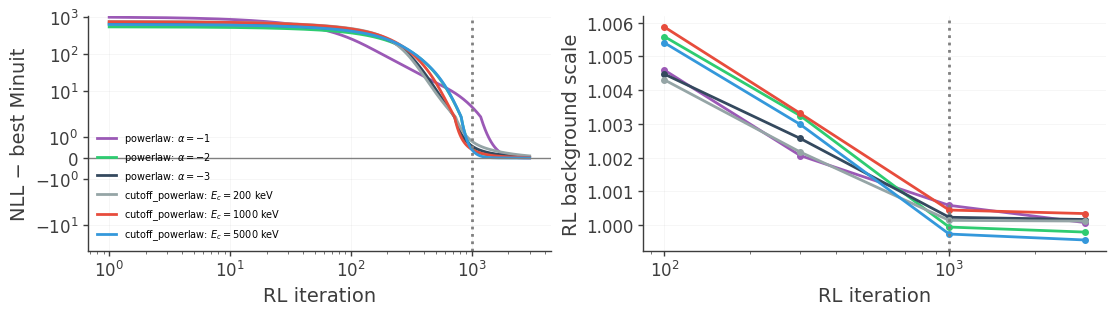

In [12]:
def plot_rl_diagnostics(runs=None):
    runs = comparison_runs if runs is None else runs
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.0), layout="constrained")
    fig.get_layout_engine().set(w_pad=0.02, h_pad=0.02, wspace=0.02)
    for run in runs:
        rl_fit = run["sed_fits"]["spectral RL"]
        label = f"{run['family']}: {run['case_label']}"
        best = min(run["sed_fits"][name]["nll"] for name in METHOD_ORDER[:2])
        iteration = np.arange(1, len(rl_fit["nll_trace"]))
        gap = rl_fit["nll_trace"][1:] - best
        axes[0].plot(iteration, gap, label=label)
        snapshots = rl_fit["snapshots"]
        axes[1].plot(list(snapshots), [s["background_scale"] for s in snapshots.values()],
                     marker="o", ms=4, label=label)
    axes[0].set(xscale="log", yscale="symlog", xlabel="RL iteration",
                ylabel="NLL − best Minuit")
    axes[0].axhline(0, color="0.5", lw=1)
    axes[1].set(xscale="log", xlabel="RL iteration", ylabel="RL background scale")
    for ax in axes:
        ax.axvline(RL_ITERATIONS, color="0.5", ls=":")
        ax.grid(alpha=0.2)
    axes[0].legend(fontsize=7, frameon=False)
    plt.show()


plot_rl_diagnostics()


## Inline comparisons

Each row is one injection: SED on the left and reported-value/truth ratio on the right, both log-log. White-filled circles, diamonds and squares denote likelihood detections; downward triangles denote their TS < 4 nominal 95% upper limits. Green plus markers are RL reconstructions, not classified detections, with no uncertainty bars.

The black dashed line is differential injected truth; black crosses show bin-averaged truth for RL. The ratio panel uses differential truth for likelihood points and bin-average truth for RL. This avoids interpreting cutoff curvature within a bin as RL bias. SED limits adapt to the plotted values and uncertainty endpoints, retaining a minimum display floor of 1e-5. Shorter panels and one shared legend reduce unused space. No plot titles or plot files are produced.

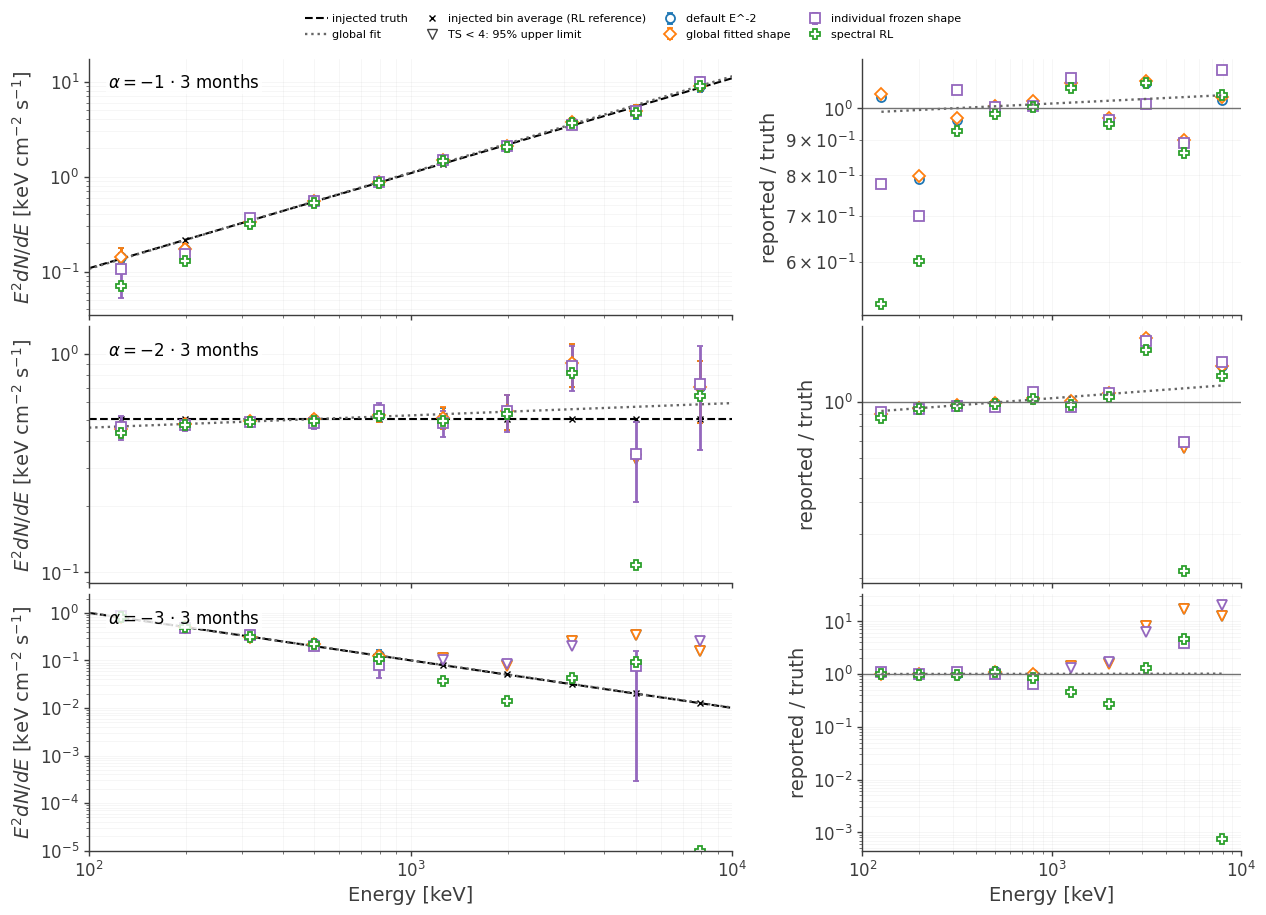

In [23]:
METHOD_STYLE = {
    "default E^-2": {"marker": "o", "color": "tab:blue"},
    "global fitted shape": {"marker": "D", "color": "tab:orange"},
    "individual frozen shape": {"marker": "s", "color": "tab:purple"},
    "spectral RL": {"marker": "P", "color": "tab:green"},
}


def plot_family_comparison(family, runs=None, results=None, exposure_months=3):
    runs = comparison_runs if runs is None else runs
    results = sed_results if results is None else results
    selected_runs = [run for run in runs if run["family"] == family]
    fig, axes = plt.subplots(
        len(selected_runs), 2, figsize=(12.5, 3.0 * len(selected_runs)),
        sharex="col", gridspec_kw={"width_ratios": (1.7, 1.0)},
        layout="constrained",
    )
    fig.get_layout_engine().set(
        w_pad=0.02, h_pad=0.02, wspace=0.02, hspace=0.02,
        rect=(0, 0, 1, 0.945),  # Reserve a compact, explicit legend band.
    )
    plot_energy = np.geomspace(ei_edges[0], ei_edges[-1], 500)

    for row, run in enumerate(selected_runs):
        ax_sed, ax_residual = axes[row]
        truth_curve = np.asarray(run["truth_shape"](plot_energy), dtype=float)
        global_shape = run["global_fit"]["shape"]
        global_curve = np.asarray(global_shape(plot_energy), dtype=float)
        ax_sed.plot(
            plot_energy, plot_energy**2 * truth_curve, "k--", lw=1.5,
            label="injected truth",
        )
        ax_sed.plot(
            plot_energy, plot_energy**2 * global_curve, color="0.4",
            ls=":", lw=1.7, label="global fit",
        )

        case_results = results[
            (results["family"] == family)
            & (results["case_value"] == run["case_value"])
        ]
        ax_sed.plot(
            energy, energy**2 * run["truth_band_flux"] / energy_widths,
            "kx", ms=5, label="injected bin average (RL reference)",
        )
        for method, style in METHOD_STYLE.items():
            table = case_results[case_results["method"] == method].sort_values("bin")
            x = table["energy_keV"].to_numpy()
            is_rl = method == "spectral RL"
            detected = (np.ones(len(table), dtype=bool) if is_rl
                        else ~table["is_ul"].to_numpy(dtype=bool))
            upper = ~detected
            y = x**2 * table["flux"].to_numpy()
            yerr = x**2 * table["flux_error"].to_numpy()
            ax_sed.errorbar(
                x[detected], y[detected], yerr=None if is_rl else yerr[detected],
                fmt=style["marker"], ms=6.5, capsize=2,
                color=style["color"], markerfacecolor="white",
                markeredgewidth=1.3, linestyle="none", label=method,
            )
            if np.any(upper):
                ul_y = x[upper]**2 * table.loc[upper, "ul95"].to_numpy()
                ax_sed.plot(
                    x[upper], ul_y, marker="v", ms=6.5,
                    color=style["color"], markerfacecolor="white",
                    markeredgewidth=1.3, linestyle="none",
                )
            detection_ratio = (
                table.loc[detected, "flux"].to_numpy()
                / table.loc[detected, "truth"].to_numpy()
            )
            ax_residual.plot(
                x[detected], detection_ratio,
                marker=style["marker"],
                ms=6.5, color=style["color"], markerfacecolor="white",
                markeredgewidth=1.3, linestyle="none", label=method,
            )
            if np.any(upper):
                ul_ratio = (
                    table.loc[upper, "ul95"].to_numpy()
                    / table.loc[upper, "truth"].to_numpy()
                )
                ax_residual.plot(
                    x[upper], ul_ratio, marker="v", ms=6.5,
                    color=style["color"], markerfacecolor="white",
                    markeredgewidth=1.3, linestyle="none",
                )

        global_at_bins = np.asarray(global_shape(energy), dtype=float)
        truth_at_bins = np.asarray(run["truth_shape"](energy), dtype=float)
        global_ratio = global_at_bins / truth_at_bins
        ax_residual.plot(
            energy, global_ratio, color="0.4", ls=":", lw=1.7,
            label="global fit",
        )

        ax_sed.text(
            0.03, 0.94, f"{run['case_label']} · {exposure_months:g} months", transform=ax_sed.transAxes, va="top",
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.8, "pad": 1.5},
        )
        ax_sed.set_xscale("log")
        ax_sed.set_yscale("log")
        ax_sed.set_xlim(ei_edges[0], ei_edges[-1])
        # Autoscale includes the curves, detections, ULs and error bars.
        # Keep the established floor for very faint cutoff tails, but do
        # not force bright spectra to include empty decades below the data.
        # A bar extending through zero still needs the full positive
        # display range down to the established logarithmic floor.
        y_min = (1.0e-5 if ax_sed.dataLim.ymin <= 0 else
                 max(1.0e-5, ax_sed.dataLim.minpos[1]))
        y_max = max(ax_sed.dataLim.ymax, y_min * 1.01)
        log_padding = 0.08 * max(np.log10(y_max / y_min), 0.5)
        ax_sed.set_ylim(
            max(1.0e-5, y_min / 10**log_padding),
            y_max * 10**log_padding,
        )
        ax_sed.set_ylabel(r"$E^2 dN/dE$ [keV cm$^{-2}$ s$^{-1}$]")
        ax_sed.grid(alpha=0.2, which="both")
        ax_residual.axhline(1.0, color="0.45", lw=1.0)
        ax_residual.set_xscale("log")
        ax_residual.set_yscale("log")
        ax_residual.set_xlim(ei_edges[0], ei_edges[-1])
        ax_residual.set_ylabel("reported / truth")
        ax_residual.grid(alpha=0.2, which="both")

        if row == 0:
            ax_sed.plot(
                [], [], marker="v", ms=6.5, color="0.25",
                markerfacecolor="white", linestyle="none",
                label="TS < 4: 95% upper limit",
            )
            handles, labels = ax_sed.get_legend_handles_labels()
            fig.legend(
                handles, labels, loc="upper center",
                bbox_to_anchor=(0.5, 0.997), borderaxespad=0,
                ncol=4, frameon=False, fontsize=8,
                columnspacing=1.2, handletextpad=0.4,
            )

    axes[-1, 0].set_xlabel("Energy [keV]")
    axes[-1, 1].set_xlabel("Energy [keV]")
    fig.canvas.draw()  # Settle layout before the inline backend crops it.
    plt.show()


plot_family_comparison("powerlaw")

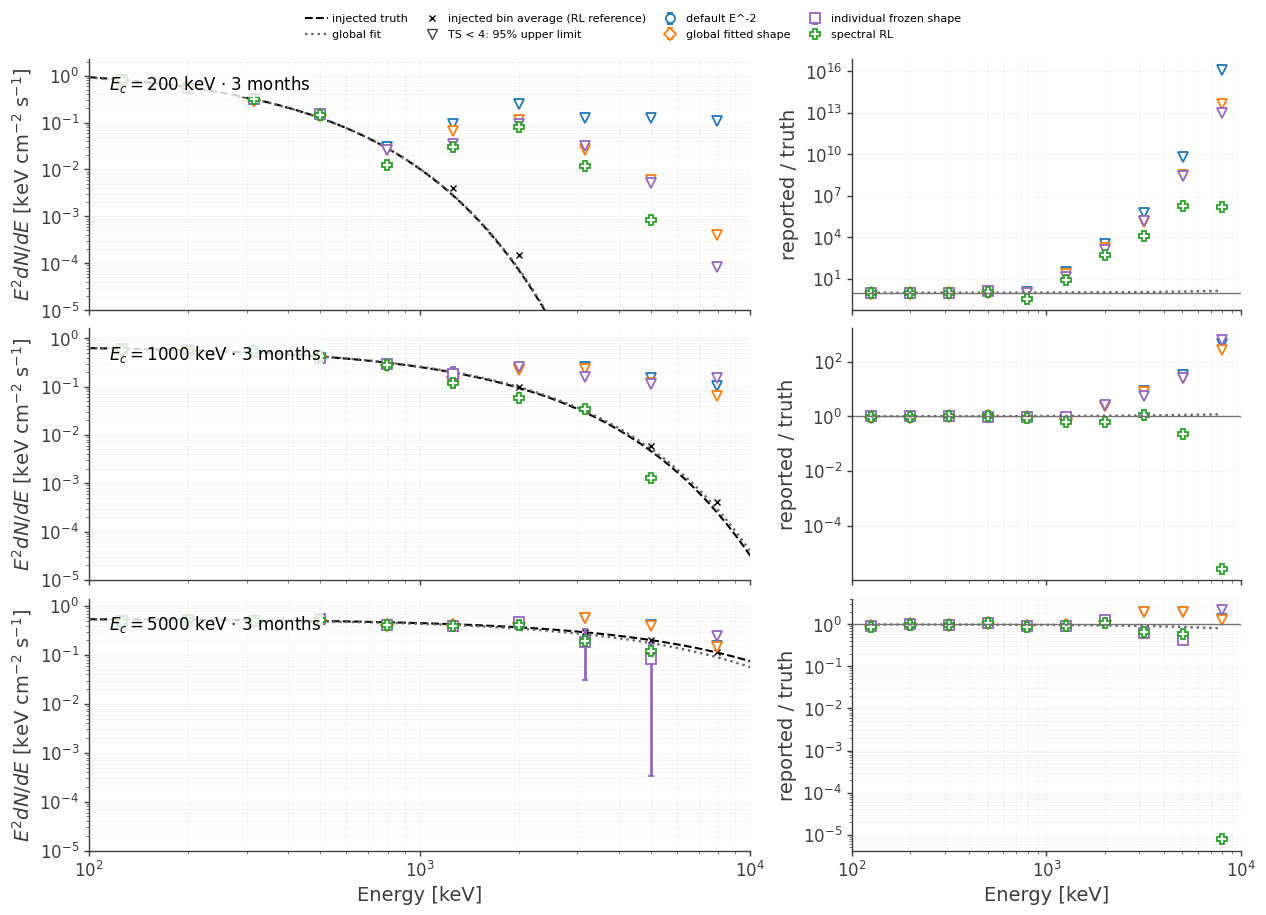

In [26]:
plot_family_comparison("cutoff_powerlaw")

## Interpretation and limitations

These results use one reproducible Poisson realization per injection. Change RANDOM_SEED to explore another realization. A single realization cannot establish bias, variance or confidence-interval coverage.

The point-source response has one column per incident-energy bin. For this response discretization, changing the within-bin SED shape rescales the column-to-differential-flux conversion. Both simultaneous SED models therefore describe the same count-space model in integrated-bin-flux coordinates. Converged spectral RL with the same free background should approach the same non-negative Poisson optimum, subject to matching bounds and possible degeneracies. It is not an independent source of additional information.

RL stops after a finite number of iterations: initialization and stopping affect its spectrum, especially in weak, correlated bins. The 100/300/1000/3000 checkpoints reveal this sensitivity. The likelihood gap to Minuit is the convergence diagnostic; a visually close curve is not sufficient. The branch's fixed-background RL was adapted to jointly update the background using COSIPy's standard ML-EM background step, without spatial smoothing or acceleration.

Individual measured-energy points rely on the frozen full-spectrum proportions when translating measured counts to incident flux; they are not independent true-energy unfolding measurements. Their extra per-slice background freedom also matters.

Global-shape uncertainty is not propagated in either frozen method. Hessian uncertainties are local approximations; the conditional upper limits and TS-based reporting selection have not been coverage-calibrated. RL has no intervals or TS labels here. The integrated-flux tables use best-fit amplitudes, including weak bins, not upper-limit values. Extremely small injected tail fluxes can produce enormous relative residuals.

## 24-month exposure comparison

Repeat all four methods for the same six spectra at eight times the original exposure. This follows the count multiplier used on `AGN_Paper_Plots`, with the consistent orientation/response scaling used in the two-method fluctuated tutorial.

We keep the physical injected flux unchanged, multiply the FOV-cut orientation's livetime weights by eight, build the corresponding point-source response, and multiply the expected background by eight. The spectral RL response is scaled consistently too. We draw fresh `Poisson(8 * (source + background))` counts, not eight times an already noisy histogram. All four methods share each new realization. The expected noise-to-signal ratio decreases by `1 / sqrt(8)`.

This is an effective-exposure projection using eight repeats of the same selected DC4 attitude and occultation distribution, not a newly simulated chronological 24-month pointing history. The weighted orientation retains its original timestamps and geometry and is used only for exposure integration.

The background remains free: one scale for each simultaneous SED fit, one per measured-energy slice for the individual method, and one jointly updated scale for spectral RL. The global shape is fitted anew at 24 months. The three likelihood methods retain TS < 4 upper limits; RL has no TS, upper limits, or uncertainty bars. RL uses the same data-independent initial flux and 1000 reported iterations (checkpoints through 3000); more exposure does not remove finite-iteration effects. No data or plot files are saved.

At high exposure, a TS null fit can put positive observed counts over a zero template cell. The likelihood retains the existing tiny positive expectation floor and evaluates log ratios stably to avoid floating-point overflow. This numerical safeguard does not resolve the physical implications of zero-background template cells or calibrate TS/upper-limit coverage.

In [15]:
BASE_EXPOSURE_MONTHS = 3.0
LONG_EXPOSURE_MONTHS = 24.0
EXPOSURE_FACTOR = LONG_EXPOSURE_MONTHS / BASE_EXPOSURE_MONTHS

# Exposure-weighted reuse of the already FOV-selected geometry.
# No extra factor is applied to truth_shape.K: source counts scale through
# the orientation, while the fit uses the correspondingly scaled response.
orientation_24m = SpacecraftHistory(
    obstime=orientation.obstime,
    attitude=orientation.attitude,
    location=orientation.location,
    livetime=orientation.livetime * EXPOSURE_FACTOR,
)
background_counts_24m = background_counts * EXPOSURE_FACTOR
scatt_map_24m = orientation_24m.get_scatt_map(
    nside=2 * data_definition.axes["PsiChi"].nside,
    target_coord=SOURCE_COORD,
    earth_occ=True,
)
np.testing.assert_allclose(
    scatt_map_24m.weights, EXPOSURE_FACTOR * scatt_map.weights, rtol=1e-10
)
point_response_24m = PointSourceResponse.from_scatt_map(
    SOURCE_COORD, data_definition, instrument_response, scatt_map_24m,
    detector_response.axes["Ei"],
    detector_response.axes["Pol"]
    if "Pol" in detector_response.axes.labels else None,
)
np.testing.assert_allclose(
    orientation_24m.cumulative_livetime().to_value(u.s),
    EXPOSURE_FACTOR * orientation.cumulative_livetime().to_value(u.s),
)

# Construct the RL response from the scaled folding path and verify its units
# through the same integrated-flux normalization used at three months.
reference_templates_24m = folded_sed_templates(
    reference_sed, SED_START_FLUXES[1], response=point_response_24m,
)
rl_response_24m = (
    reference_templates_24m.reshape(len(energy), -1)
    / reference_band_flux[:, None]
)
np.testing.assert_allclose(
    rl_response_24m, EXPOSURE_FACTOR * rl_response, rtol=1e-9, atol=1e-9,
)

display(pd.DataFrame({
    "exposure_months": [BASE_EXPOSURE_MONTHS, LONG_EXPOSURE_MONTHS],
    "selected_livetime_s": [
        orientation.cumulative_livetime().to_value(u.s),
        orientation_24m.cumulative_livetime().to_value(u.s),
    ],
    "expected_background_counts": [
        background_counts.sum(), background_counts_24m.sum(),
    ],
    "relative_Poisson_noise_vs_3m": [1.0, 1.0 / np.sqrt(EXPOSURE_FACTOR)],
}))

,exposure_months,selected_livetime_s,expected_background_counts,relative_Poisson_noise_vs_3m
0,3.0,980415.0,25071034.0,1.000000
1,24.0,7843320.0,200568272.0,0.353553


### Inject the 24-month data and fit the global spectra

The separate seed stream leaves the original three-month data unchanged. Source-count assertions check injection and response scaling in every measured-data bin.

In [16]:
comparison_runs_24m = []
global_diagnostics_24m = []
count_rows_24m = []
case_seeds_24m = np.random.SeedSequence([RANDOM_SEED, int(LONG_EXPOSURE_MONTHS)]).spawn(len(case_definitions))

for case_number, case in enumerate(case_definitions):
    family = case["family"]
    case_value = float(case["case_value"])
    tag = f"exposure24m_{family}_{case_number}"
    truth_shape = make_injected_spectrum(family, case_value)

    injected_hist = injector.inject_point_source(
        spectrum=truth_shape,
        coordinate=SOURCE_COORD,
        orientation=orientation_24m,
        source_name=tag,
        data_save_path=None,
        project_axes=["Em", "Phi", "PsiChi"],
        earth_occ=True,
    )
    source_counts = dense_values(injected_hist)
    base_source = dense_values(point_response.get_expectation(truth_shape))
    scaled_source = dense_values(point_response_24m.get_expectation(truth_shape))
    np.testing.assert_allclose(
        scaled_source, EXPOSURE_FACTOR * base_source, rtol=1e-9, atol=1e-9
    )
    np.testing.assert_allclose(source_counts, scaled_source, rtol=1e-9, atol=1e-9)
    if source_counts.shape != background_counts_24m.shape:
        raise ValueError(
            f"Source shape {source_counts.shape} does not match "
            f"background shape {background_counts_24m.shape}."
        )
    expected_counts = background_counts_24m + source_counts
    if not np.all(np.isfinite(expected_counts)) or np.any(expected_counts < 0):
        raise ValueError("Poisson expectations must be finite and non-negative.")
    rng = np.random.default_rng(case_seeds_24m[case_number])
    data = rng.poisson(expected_counts)
    count_rows_24m.append({
        "family": family,
        "case": case["case_label"],
        "expected_source_counts": float(source_counts.sum()),
        "expected_background_counts": float(background_counts_24m.sum()),
        "expected_total_counts": float(expected_counts.sum()),
        "observed_total_counts": int(data.sum()),
        "total_count_pull": (
            (data.sum() - expected_counts.sum()) / np.sqrt(expected_counts.sum())
        ),
    })
    global_fit = fit_global_spectrum(
        data, family, tag,
        response=point_response_24m, background=background_counts_24m,
    )
    global_diagnostics_24m.append(global_fit["diagnostics"])
    comparison_runs_24m.append(
        {**case, "tag": tag, "truth_shape": truth_shape,
         "global_fit": global_fit, "data": data}
    )

print(f"24-month Poisson seed: [{RANDOM_SEED}, 24]; shared counts for all four methods")
count_summary_24m = pd.DataFrame(count_rows_24m)
display(count_summary_24m)

global_rows_24m = []
for run in comparison_runs_24m:
    shape = run["global_fit"]["shape"]
    global_rows_24m.append(
        {
            "family": run["family"],
            "case": run["case_label"],
            "fitted_K": float(shape.K.value),
            "fitted_index": float(shape.index.value),
            "fitted_cutoff_keV": (
                float(shape.xc.value) if hasattr(shape, "xc") else np.nan
            ),
            "background_scale": run["global_fit"]["background_scale"],
            "nll": run["global_fit"]["nll"],
        }
    )
global_fit_table_24m = pd.DataFrame(global_rows_24m)
display(global_fit_table_24m)

global_start_diagnostics_24m = pd.concat(global_diagnostics_24m, ignore_index=True)
display(global_start_diagnostics_24m)

24-month Poisson seed: [20260909, 24]; shared counts for all four methods


,family,case,expected_source_counts,expected_background_counts,expected_total_counts,observed_total_counts,total_count_pull
0,powerlaw,$\alpha=-1$,1.789259e+06,200568272.0,2.023575e+08,202364509,0.490530
1,powerlaw,$\alpha=-2$,1.714959e+06,200568272.0,2.022832e+08,202278637,-0.322994
2,powerlaw,$\alpha=-3$,1.250144e+06,200568272.0,2.018184e+08,201824680,0.440935
3,cutoff_powerlaw,$E_c=200$ keV,1.219932e+06,200568272.0,2.017882e+08,201780599,-0.535396
4,cutoff_powerlaw,$E_c=1000$ keV,1.594621e+06,200568272.0,2.021629e+08,202155387,-0.527893
5,cutoff_powerlaw,$E_c=5000$ keV,1.698988e+06,200568272.0,2.022673e+08,202278367,0.780968


,family,case,fitted_K,fitted_index,fitted_cutoff_keV,background_scale,nll
0,powerlaw,$\alpha=-1$,1.074083e-06,-1.000103,NaN,1.000130,100536.601374
1,powerlaw,$\alpha=-2$,4.915002e-07,-2.012774,NaN,1.000091,98834.385652
2,powerlaw,$\alpha=-3$,9.780104e-08,-3.010864,NaN,1.000070,98175.062188
3,cutoff_powerlaw,$E_c=200$ keV,1.507756e-06,-2.000000,203.114112,0.999948,97737.775726
4,cutoff_powerlaw,$E_c=1000$ keV,6.958207e-07,-2.000000,995.313568,0.999931,98362.436787
5,cutoff_powerlaw,$E_c=5000$ keV,5.521019e-07,-2.000000,4979.997038,0.999992,98520.680088


,family,tag,start,nll,error,valid,edm,call_limit
0,powerlaw,exposure24m_powerlaw_0,-1.0,100536.601374,,True,3.006215e-07,False
1,powerlaw,exposure24m_powerlaw_0,-2.0,100536.601374,,True,2.939569e-07,False
2,powerlaw,exposure24m_powerlaw_0,-3.0,100536.601374,,True,7.472689e-07,False
3,powerlaw,exposure24m_powerlaw_1,-1.0,98834.385653,,True,6.119339e-07,False
4,powerlaw,exposure24m_powerlaw_1,-2.0,98834.385652,,True,4.093706e-08,False
5,powerlaw,exposure24m_powerlaw_1,-3.0,98834.385679,,True,2.676777e-05,False
6,powerlaw,exposure24m_powerlaw_2,-1.0,98175.062194,,True,6.653801e-06,False
7,powerlaw,exposure24m_powerlaw_2,-2.0,98175.062188,,True,3.705985e-07,False
8,powerlaw,exposure24m_powerlaw_2,-3.0,98175.062189,,True,2.182241e-06,False
9,cutoff_powerlaw,exposure24m_cutoff_powerlaw_3,200.0,97737.775726,,True,4.128294e-07,False


### Fit all four methods at 24 months

The helpers receive the scaled response and background explicitly. The original three-month response, background, and results are not overwritten.

In [17]:
sed_rows_24m = []
sed_diagnostics_24m = []
sed_ts_diagnostics_24m = []
rl_checkpoint_rows_24m = []
equivalence_rows_24m = []

for run in comparison_runs_24m:
    print(f"Fitting {run['family']}: {run['case_label']}", flush=True)
    data = run["data"]
    global_shape = run["global_fit"]["shape"]
    fits = {
        "default E^-2": fit_binned_sed(
            data, f"{run['tag']}_default",
            response=point_response_24m, background=background_counts_24m,
        ),
        "global fitted shape": fit_binned_sed(
            data, f"{run['tag']}_global_shape", spectral_shape=global_shape,
            response=point_response_24m, background=background_counts_24m,
        ),
        "individual frozen shape": fit_individual_frozen_shape(
            data, f"{run['tag']}_individual", global_shape,
            response=point_response_24m, background=background_counts_24m,
        ),
    }
    # Check the response normalization independently of the SED pivots.
    true_band_flux = np.asarray(get_integral_values(run["truth_shape"], ei_edges))
    truth_fold = dense_values(point_response_24m.get_expectation(run["truth_shape"])).ravel()
    np.testing.assert_allclose(true_band_flux @ rl_response_24m, truth_fold, rtol=1e-10, atol=1e-10)
    rl_fit = run_spectral_rl(
        data, response_matrix=rl_response_24m, background=background_counts_24m,
    )
    fits["spectral RL"] = rl_fit
    run["sed_fits"] = fits
    run["truth_band_flux"] = true_band_flux
    truth_center = np.asarray(run["truth_shape"](energy), dtype=float)
    for method, fit in fits.items():
        is_rl = method == "spectral RL"
        assert fit["background_free"]
        if not is_rl:
            assert fit["ts_diagnostics"]["background_free"].all()
            sed_diagnostics_24m.append(fit["diagnostics"].assign(
                family=run["family"], case=run["case_label"], method=method
            ))
            sed_ts_diagnostics_24m.append(fit["ts_diagnostics"].assign(
                family=run["family"], case=run["case_label"], method=method
            ))
            factor = (
                fit["band_factor"] if method == "individual frozen shape"
                else band_conversion(fit["spectrum"].spectral_shape)
            )
            fit["band_flux"] = fit["flux"] * factor
            fit["band_factor"] = factor
        for i in range(len(energy)):
            truth_value = true_band_flux[i] / energy_widths[i] if is_rl else truth_center[i]
            background = np.broadcast_to(fit["background_scale"], energy.shape)[i]
            sed_rows_24m.append({
                "family": run["family"], "case": run["case_label"],
                "case_value": run["case_value"], "method": method, "bin": i,
                "energy_keV": energy[i], "flux": fit["flux"][i],
                "flux_error": np.nan if is_rl else fit["error"][i],
                "error_method": ("none" if is_rl else
                    np.broadcast_to(fit["error_method"], energy.shape)[i]),
                "TS": np.nan if is_rl else fit["TS"][i],
                # None means RL was not classified, rather than a detection.
                "is_ul": None if is_rl else bool(fit["is_ul"][i]),
                "ul95": np.nan if is_rl else fit["ul95"][i],
                "truth": truth_value,
                "flux_definition": "bin average" if is_rl else "bin-center differential",
                "residual_percent": 100 * (fit["flux"][i] / truth_value - 1),
                "band_flux": fit["band_flux"][i],
                "truth_band_flux": true_band_flux[i],
                "band_residual_percent": 100 * (fit["band_flux"][i] / true_band_flux[i] - 1),
                "background_scale": background,
            })
    default, frozen = fits["default E^-2"], fits["global fitted shape"]
    count_models = {}
    for label, fit in (("default", default), ("frozen", frozen)):
        count_models[label] = (
            fit["background_scale"] * background_counts_24m.ravel()
            + fit["band_flux"] @ rl_response_24m
        )
        np.testing.assert_allclose(
            poisson_nll(data.ravel(), count_models[label]), fit["nll"],
            rtol=1e-9, atol=1e-6,
        )
    reference_nll = min(default["nll"], frozen["nll"])
    equivalence_rows_24m.append({
        "family": run["family"], "case": run["case_label"],
        "frozen_minus_default_nll": frozen["nll"] - default["nll"],
        "sum_abs_band_difference_over_total_flux": (
            np.sum(np.abs(default["band_flux"] - frozen["band_flux"]))
            / np.sum(default["band_flux"])
        ),
        "max_absolute_count_difference": float(np.max(np.abs(
            count_models["default"] - count_models["frozen"]
        ))),
        "RL_1000_minus_best_minuit_nll": rl_fit["nll"] - reference_nll,
    })
    for iteration, snapshot in rl_fit["snapshots"].items():
        rl_checkpoint_rows_24m.append({
            "family": run["family"], "case": run["case_label"],
            "iterations": iteration, "nll": snapshot["nll"],
            "nll_minus_best_minuit": snapshot["nll"] - reference_nll,
            "background_scale": snapshot["background_scale"],
            "max_fractional_update": snapshot["max_fractional_update"],
            "median_abs_band_residual_percent": float(np.median(np.abs(
                100 * (snapshot["band_flux"] / true_band_flux - 1)
            ))),
        })

sed_results_24m = pd.DataFrame(sed_rows_24m)
sed_start_diagnostics_24m = pd.concat(sed_diagnostics_24m, ignore_index=True)
sed_ts_fit_diagnostics_24m = pd.concat(sed_ts_diagnostics_24m, ignore_index=True)
equivalence_table_24m = pd.DataFrame(equivalence_rows_24m)
rl_checkpoint_table_24m = pd.DataFrame(rl_checkpoint_rows_24m)
assert len(sed_results_24m) == len(comparison_runs_24m) * 4 * len(energy)
assert sed_results_24m.loc[sed_results_24m.method == "spectral RL", ["TS", "ul95"]].isna().all().all()
display(sed_start_diagnostics_24m)


Fitting powerlaw: $\alpha=-1$


Fitting powerlaw: $\alpha=-2$


Fitting powerlaw: $\alpha=-3$


Fitting cutoff_powerlaw: $E_c=200$ keV


Fitting cutoff_powerlaw: $E_c=1000$ keV


Fitting cutoff_powerlaw: $E_c=5000$ keV


,tag,start_flux,nll,error,valid,edm,call_limit,error_method,covariance_refinement_accepted,family,case,method,measured_bin
0,exposure24m_powerlaw_0_default,1.000000e-09,100528.884982,,True,5.018405e-05,False,NaN,NaN,powerlaw,$\alpha=-1$,default E^-2,NaN
1,exposure24m_powerlaw_0_default,1.000000e-07,100528.884967,,True,3.441058e-05,False,NaN,NaN,powerlaw,$\alpha=-1$,default E^-2,NaN
2,exposure24m_powerlaw_0_default,1.000000e-05,100528.884995,,True,6.307336e-05,False,NaN,NaN,powerlaw,$\alpha=-1$,default E^-2,NaN
3,exposure24m_powerlaw_0_default,NaN,100528.884935,,True,NaN,False,Minuit HESSE,True,powerlaw,$\alpha=-1$,default E^-2,NaN
4,exposure24m_powerlaw_0_global_shape,1.000000e-09,100528.884969,,True,1.546839e-05,False,NaN,NaN,powerlaw,$\alpha=-1$,global fitted shape,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,exposure24m_cutoff_powerlaw_5_individual_em_8,NaN,9030.958630,,True,NaN,False,Minuit HESSE,True,cutoff_powerlaw,$E_c=5000$ keV,individual frozen shape,8.0
284,exposure24m_cutoff_powerlaw_5_individual_em_9,1.000000e-09,2929.515866,,True,7.834313e-09,False,NaN,NaN,cutoff_powerlaw,$E_c=5000$ keV,individual frozen shape,9.0
285,exposure24m_cutoff_powerlaw_5_individual_em_9,1.000000e-07,2929.515868,,True,2.407400e-06,False,NaN,NaN,cutoff_powerlaw,$E_c=5000$ keV,individual frozen shape,9.0
286,exposure24m_cutoff_powerlaw_5_individual_em_9,1.000000e-05,2929.515903,,True,3.676704e-05,False,NaN,NaN,cutoff_powerlaw,$E_c=5000$ keV,individual frozen shape,9.0


### 24-month residual and TS tables

Likelihood summaries include detections only. Spectral RL summaries include all bins, without labeling them detections. This is the same selection convention as the three-month tables.

In [18]:
summary_rows_24m = []
for (family, case, method), group in sed_results_24m.groupby(["family", "case", "method"]):
    is_rl = method == "spectral RL"
    selected = group if is_rl else group.loc[~group["is_ul"].astype(bool)]
    summary_rows_24m.append({
        "family": family, "case": case, "method": method,
        "selection": "all RL bins (not detections)" if is_rl else "TS >= 4",
        "flux_definition": group["flux_definition"].iloc[0],
        "median_absolute_residual_percent": (
            np.median(np.abs(selected["residual_percent"])) if len(selected) else np.nan
        ),
        "bins_used": len(selected),
        "upper_limits_TS_lt_4": np.nan if is_rl else int(group["is_ul"].astype(bool).sum()),
        "background_min": group["background_scale"].min(),
        "background_max": group["background_scale"].max(),
    })
accuracy_summary_24m = pd.DataFrame(summary_rows_24m)
display(accuracy_summary_24m)

for family in ("powerlaw", "cutoff_powerlaw"):
    subset = accuracy_summary_24m[accuracy_summary_24m.family == family]
    print(f"Median absolute residual [%]: {family}; likelihood detections / all RL bins")
    display(subset.pivot(index="case", columns="method",
                         values="median_absolute_residual_percent").reindex(columns=METHOD_ORDER))
    print(f"Per-bin results: {family}; RL TS/UL are not defined")
    display(sed_results_24m.loc[
        sed_results_24m.family == family,
        ["case", "method", "bin", "energy_keV", "flux", "flux_error", "TS",
         "is_ul", "ul95", "truth", "flux_definition", "background_scale", "error_method"],
    ])
    for method in METHOD_ORDER[:-1]:
        print(f"TS: {family} — {method}")
        selected = sed_results_24m[(sed_results_24m.family == family) & (sed_results_24m.method == method)]
        display(selected.pivot(index=["bin", "energy_keV"], columns="case", values="TS")
                .style.format(precision=3))


,family,case,method,selection,flux_definition,median_absolute_residual_percent,bins_used,upper_limits_TS_lt_4,background_min,background_max
0,cutoff_powerlaw,$E_c=1000$ keV,default E^-2,TS >= 4,bin-center differential,1.651520,7,3.0,0.999995,0.999995
1,cutoff_powerlaw,$E_c=1000$ keV,global fitted shape,TS >= 4,bin-center differential,2.752916,7,3.0,0.999995,0.999995
2,cutoff_powerlaw,$E_c=1000$ keV,individual frozen shape,TS >= 4,bin-center differential,3.291982,9,1.0,0.994968,1.000391
3,cutoff_powerlaw,$E_c=1000$ keV,spectral RL,all RL bins (not detections),bin average,4.503417,10,NaN,1.000101,1.000101
4,cutoff_powerlaw,$E_c=200$ keV,default E^-2,TS >= 4,bin-center differential,4.269390,5,5.0,0.999940,0.999940
5,cutoff_powerlaw,$E_c=200$ keV,global fitted shape,TS >= 4,bin-center differential,0.753954,5,5.0,0.999939,0.999939
6,cutoff_powerlaw,$E_c=200$ keV,individual frozen shape,TS >= 4,bin-center differential,2.244421,5,5.0,0.999535,1.003636
7,cutoff_powerlaw,$E_c=200$ keV,spectral RL,all RL bins (not detections),bin average,261.465834,10,NaN,0.999937,0.999937
8,cutoff_powerlaw,$E_c=5000$ keV,default E^-2,TS >= 4,bin-center differential,1.152260,9,1.0,0.999987,0.999987
9,cutoff_powerlaw,$E_c=5000$ keV,global fitted shape,TS >= 4,bin-center differential,0.954015,9,1.0,0.999987,0.999987


Median absolute residual [%]: powerlaw; likelihood detections / all RL bins


method,default E^-2,global fitted shape,individual frozen shape,spectral RL
case,,,,
$\alpha=-1$,2.553257,1.969619,2.533966,4.276608
$\alpha=-2$,2.827095,2.832536,2.821978,4.594846
$\alpha=-3$,3.558153,5.508971,3.486738,7.978301


Per-bin results: powerlaw; RL TS/UL are not defined


,case,method,bin,energy_keV,flux,flux_error,TS,is_ul,ul95,truth,flux_definition,background_scale,error_method
0,$\alpha=-1$,default E^-2,0,125.892414,6.793231e-06,7.883350e-07,80.932530,False,NaN,8.624318e-06,bin-center differential,1.000207,Minuit HESSE
1,$\alpha=-1$,default E^-2,1,199.526172,5.322133e-06,1.861234e-07,837.062117,False,NaN,5.441573e-06,bin-center differential,1.000207,Minuit HESSE
2,$\alpha=-1$,default E^-2,2,316.227923,3.326396e-06,6.997604e-08,2296.404639,False,NaN,3.433398e-06,bin-center differential,1.000207,Minuit HESSE
3,$\alpha=-1$,default E^-2,3,501.186989,2.137165e-06,3.483818e-08,3862.013198,False,NaN,2.166330e-06,bin-center differential,1.000207,Minuit HESSE
4,$\alpha=-1$,default E^-2,4,794.328018,1.336997e-06,2.003296e-08,4620.088239,False,NaN,1.366861e-06,bin-center differential,1.000207,Minuit HESSE
...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,$\alpha=-3$,spectral RL,5,1258.924144,4.919979e-08,NaN,NaN,None,NaN,5.145852e-08,bin average,1.000174,none
116,$\alpha=-3$,spectral RL,6,1995.261723,1.189372e-08,NaN,NaN,None,NaN,1.292578e-08,bin average,1.000174,none
117,$\alpha=-3$,spectral RL,7,3162.279229,2.810120e-09,NaN,NaN,None,NaN,3.246798e-09,bin average,1.000174,none
118,$\alpha=-3$,spectral RL,8,5011.869895,2.690422e-09,NaN,NaN,None,NaN,8.155614e-10,bin average,1.000174,none


...

,case,$E_c=1000$ keV,$E_c=200$ keV,$E_c=5000$ keV
bin,energy_keV,,,
0,125.892414,2346.360,4451.590,1903.153
1,199.526172,8882.368,7677.100,5161.215
2,316.227923,5412.927,2327.975,5625.956
3,501.186989,2568.172,285.197,3386.787
4,794.328018,642.532,9.321,1436.824
5,1258.924144,79.011,0.000,470.969
6,1995.261723,8.548,0.000,118.899
7,3162.279229,1.723,0.000,29.895
8,5011.869895,2.534,0.000,2.783


TS: cutoff_powerlaw — global fitted shape


,case,$E_c=1000$ keV,$E_c=200$ keV,$E_c=5000$ keV
bin,energy_keV,,,
0,125.892414,2346.360,4451.590,1903.153
1,199.526172,8882.368,7677.101,5161.215
2,316.227923,5412.927,2327.975,5625.956
3,501.186989,2568.172,285.197,3386.787
4,794.328018,642.532,9.323,1436.824
5,1258.924144,79.011,0.000,470.969
6,1995.261723,8.548,0.000,118.899
7,3162.279229,1.723,0.001,29.895
8,5011.869895,2.534,0.000,2.783


TS: cutoff_powerlaw — individual frozen shape


,case,$E_c=1000$ keV,$E_c=200$ keV,$E_c=5000$ keV
bin,energy_keV,,,
0,125.892414,40291.935,43919.818,37312.422
1,199.526172,20286.625,13305.713,14128.927
2,316.227923,35485.963,14056.856,28689.853
3,501.186989,10193.535,4419.696,22178.732
4,794.328018,6104.579,5.988,8139.443
5,1258.924144,1464.036,0.000,13019.853
6,1995.261723,2817.158,0.000,9949.749
7,3162.279229,2806.018,0.000,21132.796
8,5011.869895,1401.591,0.000,21065.129


### Compact comparison across exposures

Separate tables show the same four-method residual metric at each exposure. Detection sets can change with exposure, so these medians are not a fixed-bin or ensemble accuracy test. The count summary also reports the expected statistical noise divided by the total expected source counts.

In [19]:
exposure_accuracy_summary = pd.concat([
    accuracy_summary.assign(exposure_months=BASE_EXPOSURE_MONTHS),
    accuracy_summary_24m.assign(exposure_months=LONG_EXPOSURE_MONTHS),
], ignore_index=True)
compact_exposure_tables = {}
for months in (BASE_EXPOSURE_MONTHS, LONG_EXPOSURE_MONTHS):
    for family in ("powerlaw", "cutoff_powerlaw"):
        cases = [case for case in case_definitions if case["family"] == family]
        labels = {
            case["case_label"]: (
                f"α = {case['case_value']:g}" if family == "powerlaw"
                else f"Ec = {case['case_value']:g} keV"
            ) for case in cases
        }
        selected = exposure_accuracy_summary.loc[
            (exposure_accuracy_summary.exposure_months == months)
            & (exposure_accuracy_summary.family == family)
        ]
        table = selected.pivot(
            index="case", columns="method",
            values="median_absolute_residual_percent",
        ).reindex(index=list(labels), columns=METHOD_ORDER).rename(index=labels)
        compact_exposure_tables[(months, family)] = table
        print(
            f"Median absolute residual [%]: {family}; {months:g} months; "
            "TS ≥ 4 likelihood detections / all RL bins"
        )
        display(table.style.format(precision=6, na_rep="—"))

count_exposure_summary = pd.concat([
    count_summary.assign(exposure_months=BASE_EXPOSURE_MONTHS),
    count_summary_24m.assign(exposure_months=LONG_EXPOSURE_MONTHS),
], ignore_index=True)
count_exposure_summary["expected_noise_over_source"] = (
    np.sqrt(count_exposure_summary.expected_total_counts)
    / count_exposure_summary.expected_source_counts
)
display(count_exposure_summary.sort_values(["family", "case", "exposure_months"]))

Median absolute residual [%]: powerlaw; 3 months; TS ≥ 4 likelihood detections / all RL bins


method,default E^-2,global fitted shape,individual frozen shape,spectral RL
case,,,,
α = -1,4.027769,4.352046,8.450878,7.067374
α = -2,5.120292,5.028706,8.377662,5.543656
α = -3,1.171994,1.650747,7.495277,24.117405


Median absolute residual [%]: cutoff_powerlaw; 3 months; TS ≥ 4 likelihood detections / all RL bins


method,default E^-2,global fitted shape,individual frozen shape,spectral RL
case,,,,
Ec = 200 keV,1.330277,2.822529,1.669296,360.991369
Ec = 1000 keV,6.280240,6.139657,4.798816,9.520206
Ec = 5000 keV,6.514357,6.397559,9.825129,10.340004


Median absolute residual [%]: powerlaw; 24 months; TS ≥ 4 likelihood detections / all RL bins


method,default E^-2,global fitted shape,individual frozen shape,spectral RL
case,,,,
α = -1,2.553257,1.969619,2.533966,4.276608
α = -2,2.827095,2.832536,2.821978,4.594846
α = -3,3.558153,5.508971,3.486738,7.978301


Median absolute residual [%]: cutoff_powerlaw; 24 months; TS ≥ 4 likelihood detections / all RL bins


method,default E^-2,global fitted shape,individual frozen shape,spectral RL
case,,,,
Ec = 200 keV,4.269390,0.753954,2.244421,261.465834
Ec = 1000 keV,1.651520,2.752916,3.291982,4.503417
Ec = 5000 keV,1.152260,0.954015,1.582490,2.690244


,family,case,expected_source_counts,expected_background_counts,expected_total_counts,observed_total_counts,total_count_pull,exposure_months,expected_noise_over_source
4,cutoff_powerlaw,$E_c=1000$ keV,1.993276e+05,25071034.0,2.527036e+07,25276677,1.256305,3.0,0.025220
10,cutoff_powerlaw,$E_c=1000$ keV,1.594621e+06,200568272.0,2.021629e+08,202155387,-0.527893,24.0,0.008916
3,cutoff_powerlaw,$E_c=200$ keV,1.524916e+05,25071034.0,2.522353e+07,25225733,0.439529,3.0,0.032935
9,cutoff_powerlaw,$E_c=200$ keV,1.219932e+06,200568272.0,2.017882e+08,201780599,-0.535396,24.0,0.011644
5,cutoff_powerlaw,$E_c=5000$ keV,2.123735e+05,25071034.0,2.528341e+07,25268477,-2.969317,3.0,0.023676
11,cutoff_powerlaw,$E_c=5000$ keV,1.698988e+06,200568272.0,2.022673e+08,202278367,0.780968,24.0,0.008371
0,powerlaw,$\alpha=-1$,2.236574e+05,25071034.0,2.529469e+07,25294046,-0.128323,3.0,0.022487
6,powerlaw,$\alpha=-1$,1.789259e+06,200568272.0,2.023575e+08,202364509,0.490530,24.0,0.007950
1,powerlaw,$\alpha=-2$,2.143699e+05,25071034.0,2.528540e+07,25275252,-2.018879,3.0,0.023457
7,powerlaw,$\alpha=-2$,1.714959e+06,200568272.0,2.022832e+08,202278637,-0.322994,24.0,0.008293


### Integrated-flux and RL convergence diagnostics at 24 months

The common-detection comparison selects bins detected by all three likelihood methods at this exposure. RL is never TS-classified. The likelihood-gap and iteration-checkpoint diagnostics distinguish counting noise from incomplete RL convergence.

Integrated photon flux [ph cm^-2 s^-1]: all best-fit values, including weak bins


,family,case,method,bin,energy_keV,band_flux,truth_band_flux,band_residual_percent
0,powerlaw,$\alpha=-1$,default E^-2,0,125.892414,0.000397,0.000500,-20.533792
1,powerlaw,$\alpha=-1$,default E^-2,1,199.526172,0.000493,0.000500,-1.328392
2,powerlaw,$\alpha=-1$,default E^-2,2,316.227923,0.000489,0.000500,-2.258114
3,powerlaw,$\alpha=-1$,default E^-2,3,501.186989,0.000498,0.000500,-0.472191
4,powerlaw,$\alpha=-1$,default E^-2,4,794.328018,0.000493,0.000500,-1.318226
...,...,...,...,...,...,...,...,...
235,cutoff_powerlaw,$E_c=5000$ keV,spectral RL,5,1258.924144,0.000152,0.000158,-3.412894
236,cutoff_powerlaw,$E_c=5000$ keV,spectral RL,6,1995.261723,0.000075,0.000086,-13.342798
237,cutoff_powerlaw,$E_c=5000$ keV,spectral RL,7,3162.279229,0.000040,0.000043,-7.375656
238,cutoff_powerlaw,$E_c=5000$ keV,spectral RL,8,5011.869895,0.000014,0.000019,-25.086255


Common-bin selection requires TS >= 4 in all three likelihood methods; RL is not TS-classified


,family,case,method,all_bin_median_abs_residual_percent,common_detected_bins,common_bin_median_abs_residual_percent
0,powerlaw,$\alpha=-1$,default E^-2,1.969497,10,1.969497
1,powerlaw,$\alpha=-1$,global fitted shape,1.969619,10,1.969619
2,powerlaw,$\alpha=-1$,individual frozen shape,2.533966,10,2.533966
3,powerlaw,$\alpha=-1$,spectral RL,4.276608,10,4.276608
4,powerlaw,$\alpha=-2$,default E^-2,2.827095,10,2.827095
5,powerlaw,$\alpha=-2$,global fitted shape,2.833178,10,2.833178
6,powerlaw,$\alpha=-2$,individual frozen shape,2.799975,10,2.799975
7,powerlaw,$\alpha=-2$,spectral RL,4.594846,10,4.594846
8,powerlaw,$\alpha=-3$,default E^-2,14.206746,7,5.465020
9,powerlaw,$\alpha=-3$,global fitted shape,14.248137,7,5.473088


Same count-space model: simultaneous shape choices should agree within optimizer tolerance


,family,case,frozen_minus_default_nll,sum_abs_band_difference_over_total_flux,max_absolute_count_difference,RL_1000_minus_best_minuit_nll
0,powerlaw,$\alpha=-1$,3.365421e-07,2.754676e-06,0.000425,22.114029
1,powerlaw,$\alpha=-2$,1.342283e-06,1.471163e-05,0.002092,2.371805
2,powerlaw,$\alpha=-3$,2.773424e-04,1.105692e-04,0.049369,4.026888
3,cutoff_powerlaw,$E_c=200$ keV,4.220835e-05,1.384283e-05,0.006663,5.458436
4,cutoff_powerlaw,$E_c=1000$ keV,3.220222e-06,1.221160e-05,0.003361,2.312092
5,cutoff_powerlaw,$E_c=5000$ keV,4.265166e-08,2.793098e-07,0.000036,2.788111


RL iteration sensitivity: the displayed RL SED uses RL_ITERATIONS = 1000


,family,case,iterations,nll,nll_minus_best_minuit,background_scale,max_fractional_update,median_abs_band_residual_percent
0,powerlaw,$\alpha=-1$,100,102583.626678,2054.741743,1.004805,0.006704,46.060942
1,powerlaw,$\alpha=-1$,300,100904.434363,375.549428,1.002305,0.002580,15.190915
2,powerlaw,$\alpha=-1$,1000,100550.998963,22.114029,1.000646,0.001097,4.276608
3,powerlaw,$\alpha=-1$,3000,100528.957192,0.072257,1.000225,0.000079,2.023918
4,powerlaw,$\alpha=-2$,100,102008.590414,3178.098111,1.006011,0.006652,52.549705
5,powerlaw,$\alpha=-2$,300,99908.295622,1077.803319,1.003643,0.004970,38.679840
6,powerlaw,$\alpha=-2$,1000,98832.864108,2.371805,1.000239,0.000394,4.594846
7,powerlaw,$\alpha=-2$,3000,98830.492432,0.000128,1.000084,0.000005,2.852243
8,powerlaw,$\alpha=-3$,100,101612.699741,3443.635356,1.004368,0.021483,89.514744
9,powerlaw,$\alpha=-3$,300,98927.794812,758.730427,1.002473,0.014868,44.714618


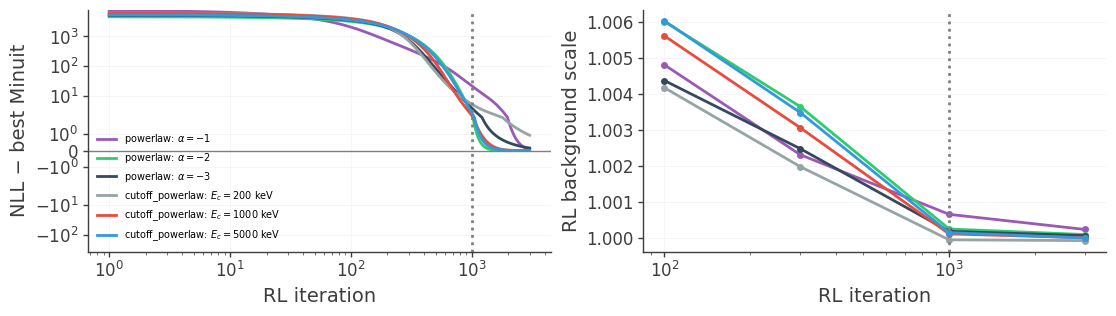

In [20]:
# These tables use best-fit integrated photon flux, NOT reported UL values.
# In the individual method this is an inference using the frozen global shape,
# not an independently unfolded true-energy measurement.
integrated_comparison_24m = sed_results_24m[
    ["family", "case", "method", "bin", "energy_keV", "band_flux",
     "truth_band_flux", "band_residual_percent"]
].copy()
integrated_rows_24m = []
for run in comparison_runs_24m:
    subset = sed_results_24m[
        (sed_results_24m.family == run["family"]) & (sed_results_24m.case_value == run["case_value"])
    ]
    common_detected = np.ones(len(energy), dtype=bool)
    for method in METHOD_ORDER[:-1]:
        table = subset[subset.method == method].sort_values("bin")
        common_detected &= ~table["is_ul"].astype(bool).to_numpy()
    for method in METHOD_ORDER:
        table = subset[subset.method == method].sort_values("bin")
        residual = table["band_residual_percent"].to_numpy()
        integrated_rows_24m.append({
            "family": run["family"], "case": run["case_label"], "method": method,
            "all_bin_median_abs_residual_percent": np.median(np.abs(residual)),
            "common_detected_bins": int(common_detected.sum()),
            "common_bin_median_abs_residual_percent": (
                np.median(np.abs(residual[common_detected])) if common_detected.any() else np.nan
            ),
        })
integrated_summary_24m = pd.DataFrame(integrated_rows_24m)
print("Integrated photon flux [ph cm^-2 s^-1]: all best-fit values, including weak bins")
display(integrated_comparison_24m)
print("Common-bin selection requires TS >= 4 in all three likelihood methods; RL is not TS-classified")
display(integrated_summary_24m)
print("Same count-space model: simultaneous shape choices should agree within optimizer tolerance")
display(equivalence_table_24m)
print("RL iteration sensitivity: the displayed RL SED uses RL_ITERATIONS = 1000")
display(rl_checkpoint_table_24m)

plot_rl_diagnostics(comparison_runs_24m)


### 24-month power-law comparison

Same compact format, injected flux, markers, and likelihood reporting conventions as the three-month comparison.

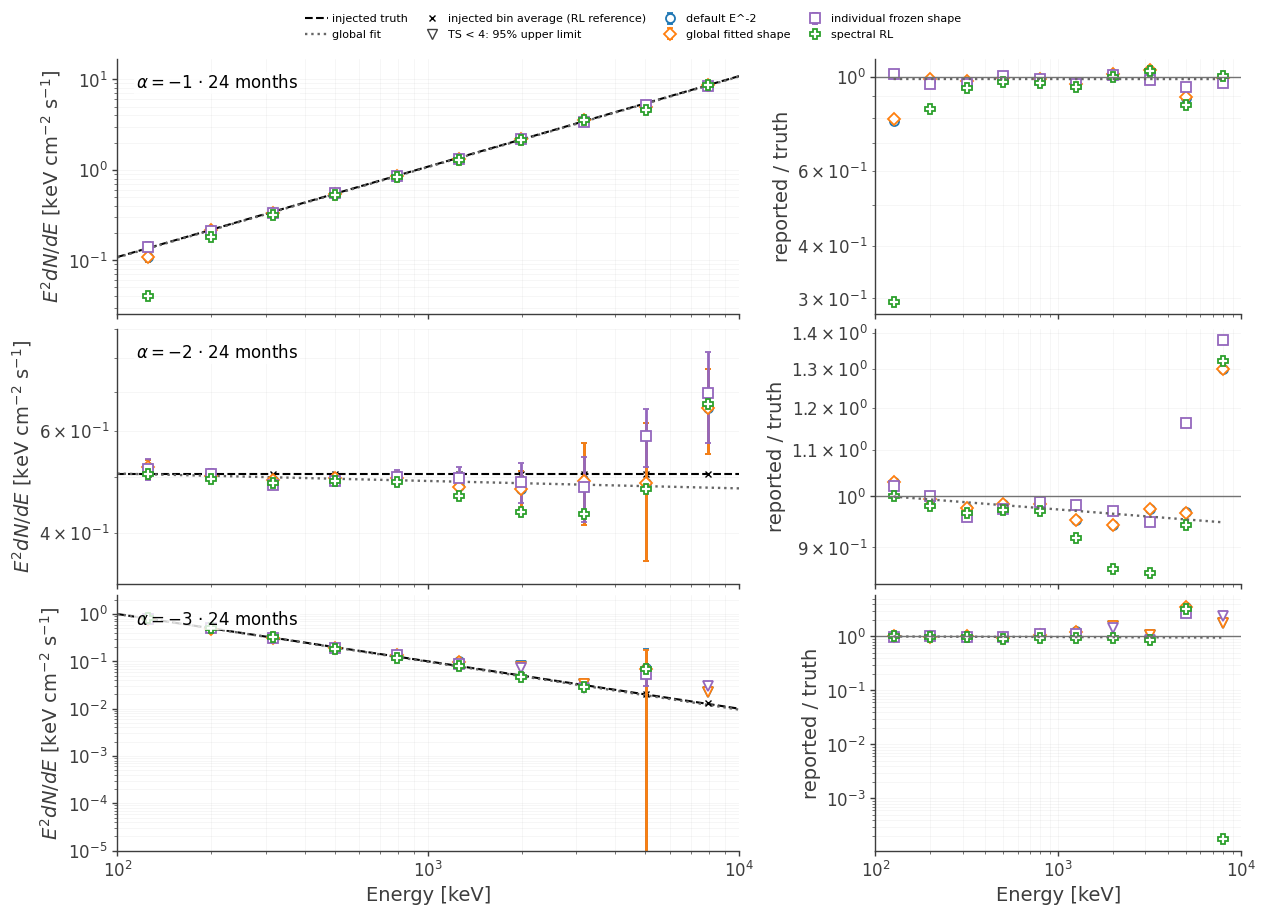

In [24]:
plot_family_comparison(
    "powerlaw", comparison_runs_24m, sed_results_24m,
    exposure_months=LONG_EXPOSURE_MONTHS,
)


### 24-month cutoff-power-law comparison

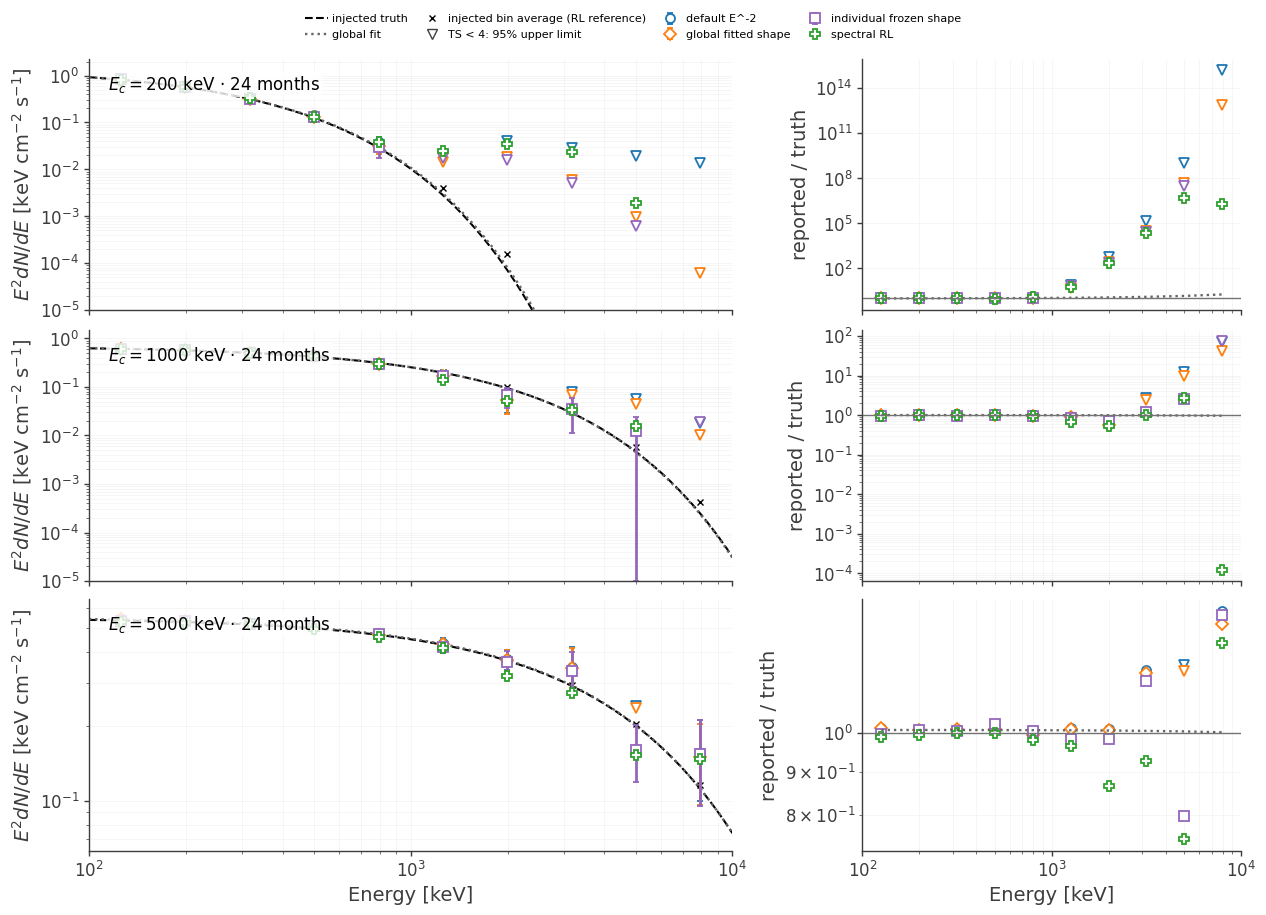

In [25]:
plot_family_comparison(
    "cutoff_powerlaw", comparison_runs_24m, sed_results_24m,
    exposure_months=LONG_EXPOSURE_MONTHS,
)
